# 1. Cài đặt thư viện

In [32]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import math
from pathlib import Path


# 2. Đọc file CSV và Sanity check

In [33]:
DATA_PATH = Path("dataset")
train_df = pd.read_csv(DATA_PATH / "train.csv")
print("Tải dữ liệu thành công!\n")

# 1. Xem hình dáng (shape) của dữ liệu
print(f"Kích thước tập dữ liệu: {train_df.shape[0]:,} dòng, {train_df.shape[1]} cột")

# 2. Xem thử 5 dòng đầu tiên để hình dung cấu trúc
display(train_df.head())

# 3. Kiểm tra kiểu dữ liệu và giá trị thiếu (Rất quan trọng)
print("\nThông tin chi tiết về các cột:")
train_df.info()

# 4. Xem thống kê mô tả nhanh cho các cột dạng số
display(train_df.describe())

C:\Users\Phanv\AppData\Local\Temp\ipykernel_13320\1067816232.py:2: DtypeWarning: Columns (0: Stt) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(DATA_PATH / "train.csv")


Tải dữ liệu thành công!

Kích thước tập dữ liệu: 711,980 dòng, 8 cột


,Date,Stt,ItemCode,Quantity,UnitPrice,SalesAmount,Unit Cost,Cost Amount
0,2020-11-17,2000004,SKU-08063,12,242700,2184300,"123559,1",1482709
1,2020-11-17,2000003,SKU-09458,600,"131818,1818",79090909,110000,66000000
2,2020-11-18,2000007,SKU-08062,6,230000,940909,101000,606000
3,2020-11-18,2000006,SKU-09458,240,270000,44181818,110000,26400000
4,2020-11-18,2000005,SKU-09458,240,270000,44181818,110000,26400000



Thông tin chi tiết về các cột:
<class 'pandas.DataFrame'>
RangeIndex: 711980 entries, 0 to 711979
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Date         711980 non-null  str   
 1   Stt          711980 non-null  object
 2   ItemCode     711980 non-null  str   
 3   Quantity     711980 non-null  int64 
 4   UnitPrice    711980 non-null  str   
 5   SalesAmount  711980 non-null  int64 
 6   Unit Cost    711980 non-null  str   
 7   Cost Amount  711980 non-null  str   
dtypes: int64(2), object(1), str(5)
memory usage: 70.1+ MB


,Quantity,SalesAmount
count,711980.000000,7.119800e+05
mean,3.437250,9.709366e+05
std,25.490722,3.888067e+06
min,-998.000000,-1.842400e+08
25%,1.000000,2.500000e+05
50%,1.000000,5.100000e+05
75%,2.000000,1.146600e+06
max,5998.000000,9.324131e+08


# 3. Các bước làm sạch dataset này bao gồm:

3.1 Clean column names: Do tên cột bị thừa khoảng trắng nên mình sẽ thay khoảng trắng = '_' <br>
3.2 Làm sạch dữ liệu giao dịch <br>
 3.2.1 Chuẩn hoá định dạng số(cột: UnitPrice / Unit_Cost / SalesAmount / Cost_Amount) <br>
 3.2.2 Chuẩn hoá định dạng thời gian (cột Date) <br>
3.3 Tạo thêm cột hàng bị trả về <br>
3.4 Xử lý anomalies <br>
3.5 Tạo thêm biến Profit


## 3.1 Clean Column Name

Clean tên cột

In [34]:
train_df.columns = (
    train_df.columns
    .str.strip()
    .str.replace(" ", "_")
)
print(train_df.columns)

Index(['Date', 'Stt', 'ItemCode', 'Quantity', 'UnitPrice', 'SalesAmount',
       'Unit_Cost', 'Cost_Amount'],
      dtype='str')


Kiểm tra missing value dạng null

In [35]:
print("\n Kiêm tra số lượng missing values trong từng cột:")
print(train_df.isnull().sum())


 Kiêm tra số lượng missing values trong từng cột:
Date           0
Stt            0
ItemCode       0
Quantity       0
UnitPrice      0
SalesAmount    0
Unit_Cost      0
Cost_Amount    0
dtype: int64


Kiểm tra missing values dạng string

In [36]:
for col in ['UnitPrice', 'Unit_Cost', 'Cost_Amount', 'SalesAmount']:
    # Kiểm tra xem có dòng nào chứa khoảng trắng hoặc chữ 'nan' không
        empty_strings = train_df[train_df[col].astype(str).str.strip().str.lower().isin(['nan', 'none', ''])]
        print(f"Cột {col} có {len(empty_strings)} dòng chứa rác ẩn dạng chuỗi.")

Cột UnitPrice có 0 dòng chứa rác ẩn dạng chuỗi.
Cột Unit_Cost có 0 dòng chứa rác ẩn dạng chuỗi.
Cột Cost_Amount có 0 dòng chứa rác ẩn dạng chuỗi.
Cột SalesAmount có 0 dòng chứa rác ẩn dạng chuỗi.


## 3.2 Làm sạch dữ liệu giao dịch

### 3.2.1 Chuẩn hoá định dạng string thành int (Cột UnitPrice / Unit_Cost / Cost_Amount)

In [37]:
# Danh sách 4 cột liên quan đến tiền tệ
money_cols = ['UnitPrice', 'Unit_Cost', 'SalesAmount', 'Cost_Amount'] 

for col in money_cols:
    # 1. Ép về string để xử lý an toàn
    # 2. str.strip() để xóa khoảng trắng thừa ở hai đầu (rất hay gặp ở cột Cost Amount)
    # 3. str.replace(',', '.') để đổi dấu thập phân kiểu VN sang chuẩn Python
    # 4. pd.to_numeric với errors='coerce' để đưa rác về NaN và ép cột về kiểu float
    
    train_df[col] = pd.to_numeric(
        train_df[col].astype(str).str.strip().str.replace(',', '.'), 
        errors='coerce'
    )
print(train_df[money_cols].dtypes)

UnitPrice      float64
Unit_Cost      float64
SalesAmount      int64
Cost_Amount    float64
dtype: object


### 3.2.2 Chuẩn hoá định dạng thời gian (Cột Date)

In [38]:
# ĐỊNH DẠNG LẠI CỘT THỜI GIAN
# Mục tiêu: Đưa chuỗi văn bản về chuẩn datetime của Pandas
train_df['Date'] = pd.to_datetime(train_df['Date'], format='%Y-%m-%d', errors='coerce')

# In ra ngày bắt đầu và ngày kết thúc để xác nhận xem có khớp với 5 năm lịch sử của đề bài không
print(f"\nDữ liệu bắt đầu từ ngày: {train_df['Date'].min().date()}")
print(f"Dữ liệu kết thúc vào ngày: {train_df['Date'].max().date()}")


Dữ liệu bắt đầu từ ngày: 2020-11-17
Dữ liệu kết thúc vào ngày: 2025-09-05


## 3.3 Tạo thêm cột hàng bị trả về "Is_Return"

In [39]:
# Returns handelling
# Mục tiêu: Tạo cột 'Is_Return' để phân loại giao dịch bán ra và trả về trên train_df.

# Thiết lập điều kiện: Cả 3 trường dữ liệu liên quan đến lượng và tiền đều phải âm
return_condition = (
    (train_df['Quantity'] < 0) & 
    (train_df['SalesAmount'] < 0) & 
    (train_df['Cost_Amount'] < 0) 
)

# Tạo Flag 'Is_Return'
train_df['Is_Return'] = return_condition.astype(int)

# Thống kê xem tổng số giao dịch trả về và tỷ lệ so với tổng giao dịch
total_returns = train_df['Is_Return'].sum()
total_transactions = len(train_df)
return_rate = (total_returns / total_transactions) * 100

print(f"Tổng số giao dịch hàng trả về: {total_returns:,} dòng")
print(f"Tỷ lệ hàng trả về chiếm: {return_rate:.2f}% tổng khối lượng giao dịch")

Tổng số giao dịch hàng trả về: 37,279 dòng
Tỷ lệ hàng trả về chiếm: 5.24% tổng khối lượng giao dịch


## 3.4 Xử lý anomalies

Xử lý anomalies sẽ bao gồm drop các:
    + Duplicate rows
    + Missing date
    + Empty SKU
    + Không có quantity nhưng lại có salesamount
    + Sản phẩm được bán ra (Quantity > 0) nhưng doanh thu âm
    + Trả hàng (Quantity < 0) nhưng ghi nhận doanh thu và cost dương

In [40]:
# Khởi tạo một đối tượng Index rỗng để chứa tất cả các dòng rác cần xóa
drop_idx = pd.Index([])

# Duplicate rows
dup_rows = train_df[train_df.duplicated()]
print(f"Số dòng trùng lặp hoàn toàn: {len(dup_rows):,}")
drop_idx = drop_idx.union(dup_rows.index)

# Mất Date (NaT do lỗi ép kiểu từ bước trước)
bad_date = train_df[train_df['Date'].isna()]
print(f"Số dòng lỗi ngày tháng (NaT): {len(bad_date):,}")
drop_idx = drop_idx.union(bad_date.index)

# Thiếu mã sản phẩm (NaN hoặc chuỗi rỗng)
empty_sku = train_df[
    (train_df['ItemCode'].isna()) | 
    (train_df['ItemCode'].astype(str).str.strip() == "")
]
print(f"Số dòng thiếu mã SKU: {len(empty_sku):,}")
drop_idx = drop_idx.union(empty_sku.index)

# Không có số lượng nhưng lại có tiền
qty_zero_sales_not_zero = train_df[
    (train_df['Quantity'] == 0) & 
    ((train_df['SalesAmount'] != 0) | (train_df['Cost_Amount'] != 0))
]
print(f"Số dòng Qty = 0 nhưng có phát sinh tiền: {len(qty_zero_sales_not_zero):,}")
drop_idx = drop_idx.union(qty_zero_sales_not_zero.index)

# Bán ra (Qty > 0) nhưng ghi nhận doanh thu âm
positive_qty_negative_sales = train_df[
    (train_df['Quantity'] > 0) & (train_df['SalesAmount'] < 0)
]
print(f"Số dòng Qty dương nhưng Doanh thu âm: {len(positive_qty_negative_sales):,}")
drop_idx = drop_idx.union(positive_qty_negative_sales.index)

# Trả hàng (Qty < 0) nhưng ghi nhận doanh thu và cost dương
negative_qty_positive_money = train_df[
    (train_df['Quantity'] < 0) & 
    ((train_df['SalesAmount'] > 0) | (train_df['Cost_Amount'] > 0))]
print(f"Số dòng Qty âm nhưng Tiền (Sales hoặc Cost) lại dương: {len(negative_qty_positive_money):,}")
drop_idx = drop_idx.union(negative_qty_positive_money.index)

# Thực hiện Drop toàn bộ logicial anomalies đã xác định
train_df = train_df.drop(index=drop_idx).reset_index(drop=True)
print(f"\n=> Đã xóa {len(drop_idx):,} dòng rác. Dữ liệu còn lại: {len(train_df):,} dòng.")



Số dòng trùng lặp hoàn toàn: 1,473
Số dòng lỗi ngày tháng (NaT): 0
Số dòng thiếu mã SKU: 0
Số dòng Qty = 0 nhưng có phát sinh tiền: 168
Số dòng Qty dương nhưng Doanh thu âm: 5
Số dòng Qty âm nhưng Tiền (Sales hoặc Cost) lại dương: 7

=> Đã xóa 1,648 dòng rác. Dữ liệu còn lại: 710,332 dòng.


## 3.5 Tạo biến Profit

In [41]:
print(" Đồng bộ lại dòng tiền và tính toán lợi nhuận")

# 1. TUYỆT ĐỐI KHÔNG ghi đè lên SalesAmount và Cost_Amount gốc.
# Việc ghi đè sẽ làm biến giao dịch trả hàng (âm x âm) thành doanh thu dương khổng lồ.

# 2. Tạo cột kiểm tra (Audit) độc lập để team có thể kiểm tra chênh lệch nếu muốn, 
# KHÔNG dùng cột này để tính lợi nhuận.
train_df['Calc_SalesAmount'] = train_df['Quantity'] * train_df['UnitPrice']
train_df['Calc_Cost_Amount'] = train_df['Quantity'] * train_df['Unit_Cost']

# 3. Tạo biến Profit (Lợi nhuận) CHUẨN
# Công thức: Lợi nhuận = Doanh thu gốc - Chi phí gốc (Đã được ép kiểu float ở bước trước)
train_df['LineProfit'] = train_df['SalesAmount'] - train_df['Cost_Amount']

# Tái lập lại cờ Is_Return để đảm bảo tính đồng nhất sau mọi bước filter
train_df["Is_Return"] = (
    (train_df["Quantity"] < 0) & 
    (train_df["SalesAmount"] < 0) & 
    (train_df["Cost_Amount"] < 0)
).astype(int)

# --- Thống kê nhanh để kiểm tra sức khoẻ tài chính của doanh nghiệp ---
total_profit = train_df['LineProfit'].sum()
print(f"=> Tổng lợi nhuận toàn hệ thống (5 năm): {total_profit:,.0f} VNĐ")

# Kiểm tra xem có bao nhiêu giao dịch bán cắt lỗ (Bán ra nhưng lợi nhuận âm)
loss_transactions = train_df[(train_df['Quantity'] > 0) & (train_df['LineProfit'] < 0)]

print(f"=> Số lượng giao dịch bán ra nhưng bị lỗ: {len(loss_transactions):,} dòng")
print(f"=> Tỷ lệ giao dịch lỗ: {(len(loss_transactions) / len(train_df)) * 100:.2f}%")

 Đồng bộ lại dòng tiền và tính toán lợi nhuận
=> Tổng lợi nhuận toàn hệ thống (5 năm): 168,883,971,623 VNĐ
=> Số lượng giao dịch bán ra nhưng bị lỗ: 27,370 dòng
=> Tỷ lệ giao dịch lỗ: 3.85%


# 4. Time-Series preparation

Gom nhóm theo ngày: Tính tổng cộng số lượng bán ra và lợi nhuận của từng mã hàng trong mỗi ngày <br>  
Ép Quantity < 0 về 0: Luật cuộc thi cấm kết quả dự báo là số âm nên là nếu ngày nào quantity hàng khách trả lại nhiều hơn quantity khách mua (khiến tổng quantity bị âm) thì ép quantity của cột đó về 0 <br>  
Time-series Padding: Tạo một bộ lịch trải dài liên tục suốt 5 năm, ngày nào mã hàng không bán được cái nào thì phải điền số 0 vào tuyệt đối không được để mất tích ngày đó trong dữ liệu <br>  

In [42]:
print("--- Chốt chặn cuối cùng: Xử lý phần dư của file Audit ---")

# 1. Xử lý Lỗi số 5: Tách và loại bỏ 145 dòng Quantity âm nhưng không phải trả hàng chuẩn
# Tạo cờ nhận diện nhóm "Điều chỉnh kho" vô lý
train_df["Is_Negative_Adjustment"] = (
    (train_df["Quantity"] < 0) & 
    (train_df["Is_Return"] == 0)
).astype(int)

# Thống kê nhanh và loại bỏ khỏi tập huấn luyện Demand
num_adjustments = train_df["Is_Negative_Adjustment"].sum()
print(f"=> Phát hiện {num_adjustments} dòng Quantity âm nhưng tiền không âm. Đang tiến hành loại bỏ...")

# Chỉ giữ lại những dòng KHÔNG phải là Negative Adjustment
train_df = train_df[train_df["Is_Negative_Adjustment"] == 0].copy()

# 2. Xử lý Lỗi số 6: Drop Duplicate lần cuối sau mọi phép biến đổi
len_before = len(train_df)
train_df = train_df.drop_duplicates().reset_index(drop=True)
len_after = len(train_df)

print(f"=> Đã dọn dẹp {len_before - len_after} dòng trùng lặp phát sinh sau biến đổi.")
print(f"=> Dữ liệu THỰC SỰ SẠCH cuối cùng: {len(train_df):,} dòng.")
print("--- Sẵn sàng để đưa vào bước Time-Series Aggregation ---")

--- Chốt chặn cuối cùng: Xử lý phần dư của file Audit ---
=> Phát hiện 145 dòng Quantity âm nhưng tiền không âm. Đang tiến hành loại bỏ...
=> Đã dọn dẹp 0 dòng trùng lặp phát sinh sau biến đổi.
=> Dữ liệu THỰC SỰ SẠCH cuối cùng: 710,187 dòng.
--- Sẵn sàng để đưa vào bước Time-Series Aggregation ---


## 4.1 Gom nhóm dữ liệu

In [43]:
# Aggregate dữ liệu theo ngày và mã hàng
# Mục tiêu: Đưa dữ liệu từ transaction theo ngày về tổng demand theo ngày và mã hàng để phục vụ cho việc phân tích xu hướng và dự báo sau này

print("Gom nhóm dữ liệu theo Ngày và Mã hàng")

# Dùng hàm groupby() của Pandas để nhóm các dòng có cùng 'Date' và 'ItemCode'.
# Tham số as_index=False giúp giữ 'Date' và 'ItemCode' làm cột bình thường thay vì biến thành Index.
# Sau đó, ta tính tổng (.sum()) cho 2 cột cốt lõi là 'Quantity' và 'LineProfit'.
daily_df = train_df.groupby(['Date', 'ItemCode'], as_index=False)[['Quantity', 'LineProfit']].sum()

# In ra kết quả kiểm tra
print(f"=> Thu gọn thành công --> Số dòng sau khi gom nhóm: {len(daily_df):,} dòng")
display(daily_df.head(100))

Gom nhóm dữ liệu theo Ngày và Mã hàng
=> Thu gọn thành công --> Số dòng sau khi gom nhóm: 506,883 dòng


,Date,ItemCode,Quantity,LineProfit
0,2020-11-17,SKU-08063,12,701591.0
1,2020-11-17,SKU-09458,600,13090909.0
2,2020-11-18,SKU-08062,6,334909.0
3,2020-11-18,SKU-09458,480,35563636.0
4,2020-11-20,SKU-09458,240,17781818.0
...,...,...,...,...
95,2021-01-11,SKU-02764,6,129000.0
96,2021-01-11,SKU-02950,6,319636.0
97,2021-01-11,SKU-03351,6,102754.0
98,2021-01-11,SKU-03687,12,472248.0


## 4.2 Ép quantity < 0 về 0

In [44]:
# Xử lý các row có quantity âm do khách trả hàng để đảm bảo tuân thủ quy định không có ngày nào tổng lượng bán bị âm
# Mục tiêu: Đảm bảo không có ngày nào tổng lượng bán bị âm để tránh vi phạm luật dự báo

print("Rà soát và xử lý các ngày có lượng cầu âm")

# Rà soát xem hệ thống đang có bao nhiêu ngày bị âm
negative_days = (daily_df['Quantity'] < 0).sum()
print(f"=> Phát hiện {negative_days:,} ngày có tổng lượng bán < 0 (Do quantity khách trả hàng lấn át quantity bán ra)")
# Quy trình xử lý như sau:
# Xử lý nhanh gọn bằng hàm .clip() của Pandas.
# Tham số lower=0 có nghĩa là: Bất kỳ giá trị nào nhỏ hơn 0 sẽ bị ép thành 0.
# Các giá trị lớn hơn 0 (bán bình thường) vẫn giữ nguyên
daily_df['Quantity'] = daily_df['Quantity'].clip(lower=0)

print("Đã dọn sạch các giá trị quantity âm")

Rà soát và xử lý các ngày có lượng cầu âm
=> Phát hiện 20,660 ngày có tổng lượng bán < 0 (Do quantity khách trả hàng lấn át quantity bán ra)
Đã dọn sạch các giá trị quantity âm


## 4.3 Time-series padding

In [45]:

# Điền khuyết các ngày trống
# Mục tiêu: Tạo bộ lịch liên tục 5 năm cho toàn bộ danh mục sản phẩm theo ĐÚNG yêu cầu đề thi

print("Tạo bộ dữ liệu có date liên tục và điền khuyết dữ liệu")

# 1. Tạo danh sách tất cả các ngày liên tục trong khoảng thời gian quy định
all_dates = pd.date_range(start='2020-11-17', end='2025-09-05', freq='D')

# 2. Lấy danh sách TOÀN BỘ các SKU từ mẫu nộp bài (Để đảm bảo không sót bất kỳ mã nào)
sample = pd.read_csv(DATA_PATH / "sample_submission.csv")
all_items = (
    sample["id"]
    .str.replace("_validation", "", regex=False)
    .str.replace("_evaluation", "", regex=False)
    .unique()
)
print(f"Số lượng SKU chuẩn theo yêu cầu ban tổ chức: {len(all_items):,} mã")

# 3. Tạo một cái grid chứa mọi tổ hợp có thể xảy ra giữa Date và ItemCode
grid = pd.MultiIndex.from_product(
    [all_dates, all_items], 
    names=['Date', 'ItemCode']
).to_frame(index=False)

# 4. Merge dữ liệu thực tế đang có vào lưới
full_time_series = pd.merge(grid, daily_df, on=['Date', 'ItemCode'], how='left')

# 5. Lấp đầy các lỗ hổng bị NaN
# Những ngày không có giao dịch -> Số lượng bán = 0 và Lợi nhuận = 0
full_time_series['Quantity'] = full_time_series['Quantity'].fillna(0).astype(int)
full_time_series['LineProfit'] = full_time_series['LineProfit'].fillna(0)

# Sắp xếp lại dữ liệu
full_time_series.sort_values(['Date', 'ItemCode'], inplace=True, ignore_index=True)

print(f"=> Kích thước ma trận Time-Series chuẩn mới: {len(full_time_series):,} dòng")
display(full_time_series.head())

Tạo bộ dữ liệu có date liên tục và điền khuyết dữ liệu
Số lượng SKU chuẩn theo yêu cầu ban tổ chức: 15,972 mã
=> Kích thước ma trận Time-Series chuẩn mới: 28,014,888 dòng


,Date,ItemCode,Quantity,LineProfit
0,2020-11-17,SKU-00001,0,0.0
1,2020-11-17,SKU-00002,0,0.0
2,2020-11-17,SKU-00003,0,0.0
3,2020-11-17,SKU-00004,0,0.0
4,2020-11-17,SKU-00005,0,0.0


# 5. Xuất file train_cleaned.csv

In [46]:
output_path = (
    DATA_PATH
    / "train_cleaned.csv"
)

train_df.to_csv(
    output_path,
    index=False
)

print(
    f"\nSaved file to: {output_path}"
)


Saved file to: dataset\train_cleaned.csv


# 6. EDA 

Define problem<br>

Mục tiêu kinh doanh: Tối ưu hóa lợi nhuận và giảm thiểu tồn kho  
Mục tiêu kỹ thuật: Dự báo tổng số Quantity không âm theo từng ngày  
Thước đo: Tối ưu hàm mục tiêu đánh giá 'WRMSSE' (phạt nặng các sai số trên sản phẩm có lợi nhuận cao)<br>

EDA bao gồm các câu hỏi cần phân tích: <br>

Phân tích Cấu trúc Lợi nhuận: - Done<br>
  + Xác định cashcow: Bóc tách nhóm 20% mã hàng đang gánh 80% lợi nhuận của toàn hệ thống (Dựa trên nguyên lý Pareto)
  + Xác định deadstock : Là những mã phụ tùng bán cực kỳ thưa thớt, mang lại lợi nhuận thấp, bằng 0, hoặc đặc biệt là có tổng lợi nhuận âm (profit≤0)
  --> Sử dụng BCG Growth Share Matrix
  + Phân tích Volume (khối lượng Quantity) và Biên lợi nhuận:


Kiểm tra hành vi trả hàng: - Done <br>
  + Tỷ lệ rủi ro theo ItemCode: Đánh giá tỷ lệ rủi ro trả hàng theo từng nhóm ItemCode cụ thể
  + Chu kỳ trả hàng  


Khám phá Đặc tính Chuỗi thời gian: - Done <br>
  + Đo lường độ thưa thớt: Tính tỷ lệ những ngày quantity = 0 của từng ItemCode 
  + Tính chu kỳ và Mùa vụ : Tìm kiếm sự bùng nổ doanh số theo tháng / năm 
  + Thói quen nhập hàng trong tuần/tháng: Xem thử quantity tăng mạnh nhất vào này nào trong tuần/ tháng
  + Phân tích Tự tương quan (ACF & PACF): Đo lường xem nhu cầu ngày hôm nay có tương quan mạnh nhất với ngày nào trong quá khứ (Lag 7, Lag 14 hay Lag 28)


Vòng đời Sản phẩm và Xu hướng - Done <br>
  + Xu hướng toàn công ty: Tổng doanh thu/nhu cầu của toàn công ty qua 5 năm đang trên đà tăng trưởng hay suy thoái
  + Đứt gãy do yếu tố vĩ mô: Tìm kiếm và đánh dấu các giai đoạn sập nguồn cầu bất thường (ví dụ: đợt giãn cách COVID-19 năm 2021)
  + Mã hàng lỗi thời: Nhận diện các mã phụ tùng thuộc đời xe cũ đang có xu hướng (trend) cắm đầu đi xuống qua từng năm
  + Mã hàng mới: Khoanh vùng các mã mới chỉ xuất hiện dưới 6 tháng (có ít data) để có chiến lược dự báo riêng



## 6.1 Phân tích cấu trúc lợi nhuận

### 6.1.1 Tính cummulative profit và đường công pareto

Tính tổng Lợi nhuận và vẽ đường cong Pareto


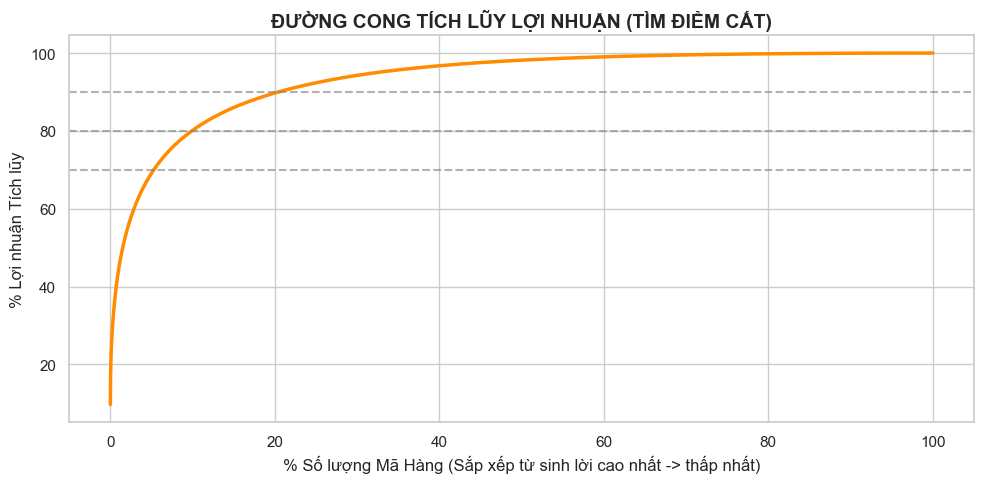

In [47]:
sns.set_theme(style="whitegrid")

print("Tính tổng Lợi nhuận và vẽ đường cong Pareto")

# 1. Tính Tổng Volume (Số lượng) và Tổng Lợi nhuận cho từng mã SKU trong suốt 5 năm
sku_summary = daily_df.groupby('ItemCode').agg(
    Total_Volume=('Quantity', 'sum'),
    Total_Profit=('LineProfit', 'sum')
).reset_index()

# 2. Bóc tách riêng nhóm có lãi để tính tỷ trọng tích lũy
profitable_skus = sku_summary[sku_summary['Total_Profit'] > 0].copy()

# Sắp xếp các mã SKU từ đứa kiếm tiền giỏi nhất xuống tệ nhất
profitable_skus.sort_values(by='Total_Profit', ascending=False, inplace=True)

# Tính % Lợi nhuận tích lũy (Cộng dồn dần dần để xem đến đâu thì đủ 100%)
profitable_skus['Cum_Profit_Pct'] = profitable_skus['Total_Profit'].cumsum() / profitable_skus['Total_Profit'].sum()

# 3. Trực quan hóa Đường cong Pareto
plt.figure(figsize=(10, 5))

# Trục X: Chuyển số lượng SKU thành phần trăm (từ 0% đến 100% danh mục)
x_pct = np.arange(1, len(profitable_skus) + 1) / len(profitable_skus) * 100
# Trục Y: % Lợi nhuận tích lũy tương ứng
plt.plot(x_pct, profitable_skus['Cum_Profit_Pct'] * 100, color='darkorange', linewidth=2.5)

plt.title('ĐƯỜNG CONG TÍCH LŨY LỢI NHUẬN (TÌM ĐIỂM CẮT)', fontsize=14, fontweight='bold')
plt.xlabel('% Số lượng Mã Hàng (Sắp xếp từ sinh lời cao nhất -> thấp nhất)')
plt.ylabel('% Lợi nhuận Tích lũy')

# Kẻ 3 đường gióng ngang để soi điểm uốn dễ hơn
for y_val in [70, 80, 90]:
    plt.axhline(y=y_val, color='gray', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# NOTE DÀNH CHO TEAM: Hãy nhìn vào biểu đồ này. Chỗ nào đường cong bẻ ngang gắt nhất, 
# hãy lấy mốc đó (ví dụ 75% hoặc 80%) để đưa vào Block 2 bên dưới.

### 6.1.2 Tìm Cashcow và Deadstock theo BCG Growth Share Matrix

In [48]:
#  Phân loại category theo BCG Matrix

print("Phân loại danh mục theo khung chiến lược BCG")

# 1. Tạo hàm phân loại (Điều chỉnh con số theo điểm uốn thực tế ở Bước 1)
def categorize_bcg_dynamic(cum_pct):
    if cum_pct <= 0.85:       # Đóng góp 85 % lợi nhuận -> Dồn 100% công lực model vào đây
        return '1. Stars & Cash Cows (Ngôi sao)'
    elif cum_pct <= 0.97:     # Đóng góp x% lợi nhuận tiếp theo -> Nhóm ổn định
        return '2. Question Marks (Dấu hỏi)'
    else:                     # Phần đuôi dài tốn resource, đóng góp ít
        return '3. Dogs'

# Dán nhãn cho nhóm SKU có lãi
profitable_skus['BCG_Class'] = profitable_skus['Cum_Profit_Pct'].apply(categorize_bcg_dynamic)

# 2. Xử lý nhóm Deadstock (Dog: Bán lỗ hoặc không sinh lời)
deadstock = sku_summary[sku_summary['Total_Profit'] <= 0].copy()
deadstock['BCG_Class'] = '4. Deadstock (Lỗ/Không lãi)'
deadstock['Cum_Profit_Pct'] = np.nan # Nhóm này không có giá trị tích lũy

# 3. Hợp nhất (Concat) lại thành một bảng Danh mục chuẩn chỉnh
final_portfolio = pd.concat([profitable_skus, deadstock], ignore_index=True)

# 4. In bảng tóm tắt để báo cáo cho Ban giám khảo/Sếp
bcg_stats = final_portfolio.groupby('BCG_Class').agg(
    So_luong_SKU=('ItemCode', 'count'),
    Tong_Loi_Nhuan=('Total_Profit', 'sum')
).reset_index()

# Thêm 2 cột tỷ trọng để thấy rõ sự chênh lệch
total_skus = len(final_portfolio)
total_profit = profitable_skus['Total_Profit'].sum() # Chỉ tính tổng của bọn có lãi

bcg_stats['Ty_trong_SKU (%)'] = (bcg_stats['So_luong_SKU'] / total_skus) * 100
bcg_stats['Ty_trong_Loi_Nhuan (%)'] = (bcg_stats['Tong_Loi_Nhuan'] / total_profit) * 100

print("\n--- BẢNG PHÂN TÍCH TỶ TRỌNG DANH MỤC ---")
display(bcg_stats.round(2))

Phân loại danh mục theo khung chiến lược BCG

--- BẢNG PHÂN TÍCH TỶ TRỌNG DANH MỤC ---


,BCG_Class,So_luong_SKU,Tong_Loi_Nhuan,Ty_trong_SKU (%),Ty_trong_Loi_Nhuan (%)
0,1. Stars & Cash Cows (Ngôi sao),1976,1.462140e+11,12.37,85.00
1,2. Question Marks (Dấu hỏi),3904,2.064991e+10,24.44,12.00
2,3. Dogs,8279,5.162435e+09,51.84,3.00
3,4. Deadstock (Lỗ/Không lãi),1812,-3.127664e+09,11.35,-1.82


### 6.1.3 Phân tích Volume (khối lượng Quantity) và Biên lợi nhuận:

Biểu đồ phân tích Volume và Biên lợi nhuận


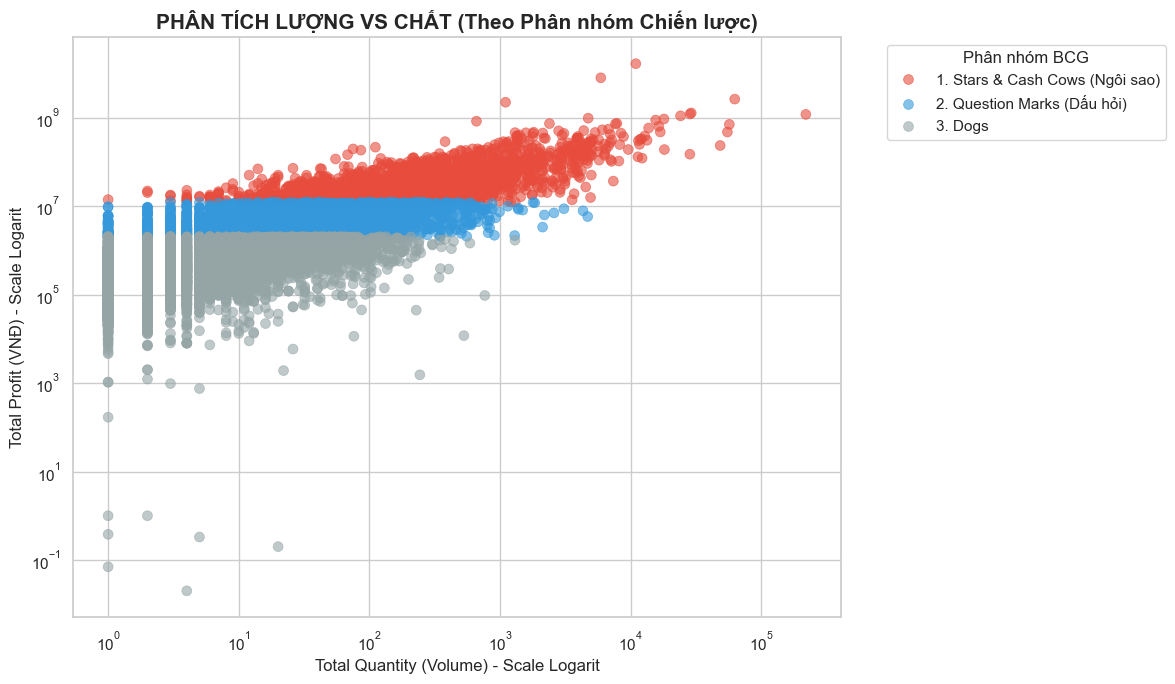

In [49]:
# TRỰC QUAN HÓA LƯỢNG VS CHẤT (SCATTER PLOT)
print("Biểu đồ phân tích Volume và Biên lợi nhuận")

plt.figure(figsize=(12, 7))

# Tạm thời cất nhóm Deadstock đi để trục Y không bị kéo tuột xuống số âm khổng lồ
plot_data = final_portfolio[final_portfolio['BCG_Class'] != '4. Deadstock (Lỗ/Không lãi)']

# Vẽ Scatter Plot (Mỗi dấu chấm là 1 mã SKU)
# hue='BCG_Class' giúp tự động tô màu theo cái nhãn ta vừa dán ở Bước 2
sns.scatterplot(
    data=plot_data, 
    x='Total_Volume', 
    y='Total_Profit', 
    hue='BCG_Class', 
    palette=['#e74c3c', '#3498db', '#95a5a6'], # Bảng màu: Đỏ, Xanh, Xám
    alpha=0.6,    # Độ trong suốt để thấy những chỗ các chấm đè lên nhau
    s=50,         # Kích thước dấu chấm
    edgecolor=None
)

# CỰC KỲ QUAN TRỌNG: Phải dùng thang đo Logarit cho cả 2 trục
# Vì dữ liệu bán lẻ thường có tail, nếu để thang tuyến tính bình thường, 90% dấu chấm sẽ bị vón cục lại ở góc trái dưới cùng của biểu đồ.
plt.xscale('log') 
plt.yscale('log')

plt.title('PHÂN TÍCH LƯỢNG VS CHẤT (Theo Phân nhóm Chiến lược)', fontsize=15, fontweight='bold')
plt.xlabel('Total Quantity (Volume) - Scale Logarit')
plt.ylabel('Total Profit (VNĐ) - Scale Logarit')

# Tối ưu cái bảng chú thích (Legend)
plt.legend(title='Phân nhóm BCG', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# NOTE DÀNH CHO TEAM: 
# - Những chấm màu Đỏ nằm tít trên cao (Trục Y cao) nhưng lùi về bên trái (Trục X thấp): Bán ít nhưng lãi cực dày.
# - Những chấm màu Xanh nằm tít bên phải (Trục X cao) nhưng lùi xuống dưới (Trục Y thấp): Bán chạy như tôm tươi nhưng lãi mỏng như lá lúa.

## 6.2 Kiểm tra hành vi trả hàng

MÔ TẢ CÁCH THỰC THI (EXECUTION WORKFLOW)<br>

1. Tính toán rủi ro và tự động dò Ngưỡng Báo Động (IQR):<br>

2. Trực quan hóa Bản đồ Rủi ro (Định vị Danger Zone):<br>

3. Khám phá Chu kỳ trả hàng (Time-Series Features):<br>


### 6.2.1 Tính Return Rate và Ngưỡng cảnh báo (xài IQR)

Tách riêng lượng bán ra và lượng khách trả vào để tính tỷ lệ trả hàng (%) cho từng mã. Thay vì tự áp đặt mức rủi ro (như 5% hay 10%), ta dùng phương pháp thống kê IQR để tự động tìm ra ngưỡng báo động (Upper Bound). Mã nào vượt ngưỡng này sẽ bị cảnh báo  

In [50]:
print("Tính tỷ lệ trả hàng và tìm ngưỡng rủi ro tự động")

# 1. Tách riêng giao dịch Bán ra (Sales) và Trả vào (Returns)
sales_tx = train_df[train_df['Quantity'] > 0]
returns_tx = train_df[train_df['Quantity'] < 0]

# 2. Tính tổng sản lượng bán và lượng hàng bị trả lại cho từng mã SKU
sales_vol = sales_tx.groupby('ItemCode')['Quantity'].sum().reset_index(name='Total_Sold')
returns_vol = returns_tx.groupby('ItemCode')['Quantity'].apply(lambda x: abs(x.sum())).reset_index(name='Total_Returned')

# 3. Hợp nhất thành Bảng Return Risk
return_risk_df = pd.merge(sales_vol, returns_vol, on='ItemCode', how='left')
# Mã nào xịn, khách không bao giờ trả thì điền số 0
return_risk_df['Total_Returned'] = return_risk_df['Total_Returned'].fillna(0) 

# Tính Tỷ lệ trả hàng (%)
return_risk_df['Return_Rate_Pct'] = (return_risk_df['Total_Returned'] / return_risk_df['Total_Sold']) * 100

# 4. Gắn nhãn BCG (từ bảng final_portfolio đã làm ở bước trước) vào chung 
return_analysis = pd.merge(
    return_risk_df, 
    final_portfolio[['ItemCode', 'BCG_Class', 'Total_Profit']], 
    on='ItemCode', 
    how='inner'
)

# 5. TỰ ĐỘNG TÌM NGƯỠNG BÁO ĐỘNG (Dùng Boxplot/IQR)
# Chỉ xét những mã CÓ BỊ TRẢ HÀNG để tính phân phối cho chuẩn
active_returns = return_analysis[return_analysis['Return_Rate_Pct'] > 0]

Q1 = active_returns['Return_Rate_Pct'].quantile(0.25)
Q3 = active_returns['Return_Rate_Pct'].quantile(0.75)
IQR = Q3 - Q1
# Hàng rào trên (Ai vượt qua vạch này là rủi ro cao)
upper_bound = Q3 + 1.5 * IQR  

print(f"=> Ngưỡng Cảnh Báo (Upper Bound) tự động chốt ở mức: {upper_bound:.2f}%")

# 6. Tạo Feature cho Mô hình Machine Learning (Cực kỳ ăn tiền)
# Gắn cờ 1 cho những mã rủi ro cao, 0 cho mã an toàn
return_analysis['Is_High_Return_Risk'] = np.where(return_analysis['Return_Rate_Pct'] > upper_bound, 1, 0)

# Lọc ra mấy con Cash Cow nhưng đang bị khách trả hàng vỡ mặt
bleeding_stars = return_analysis[
    (return_analysis['BCG_Class'].str.contains('Stars', na=False)) & 
    (return_analysis['Is_High_Return_Risk'] == 1)
].sort_values(by='Return_Rate_Pct', ascending=False)

print(f"\n=> PHÁT HIỆN: Có {len(bleeding_stars)} mã 'Ngôi sao' đang chảy máu chi phí (Vượt ngưỡng {upper_bound:.2f}%)!")
print(bleeding_stars.head(11))

Tính tỷ lệ trả hàng và tìm ngưỡng rủi ro tự động
=> Ngưỡng Cảnh Báo (Upper Bound) tự động chốt ở mức: 53.46%

=> PHÁT HIỆN: Có 2 mã 'Ngôi sao' đang chảy máu chi phí (Vượt ngưỡng 53.46%)!
       ItemCode  Total_Sold  Total_Returned  Return_Rate_Pct  \
4875  SKU-05034          61            41.0        67.213115   
5400  SKU-05575          11             6.0        54.545455   

                            BCG_Class  Total_Profit  Is_High_Return_Risk  
4875  1. Stars & Cash Cows (Ngôi sao)   19133507.80                    1  
5400  1. Stars & Cash Cows (Ngôi sao)   26154737.34                    1  


### 6.2.2 Trực quan hoá bản đồ Danger Zone


Mang tỷ lệ trả hàng kết hợp với BCG Matrix. Ta dùng biểu đồ Scatter Plot để tìm xem có mã nào trong nhóm Ngôi sao (bán cực chạy, lãi cực cao) nhưng lại đang bị trả hàng vượt mức báo động không. Đây chính là những mã đang làm ảnh hưởng đến chi phí lợi nhuận của công ty

Vẽ Bản đồ Rủi ro


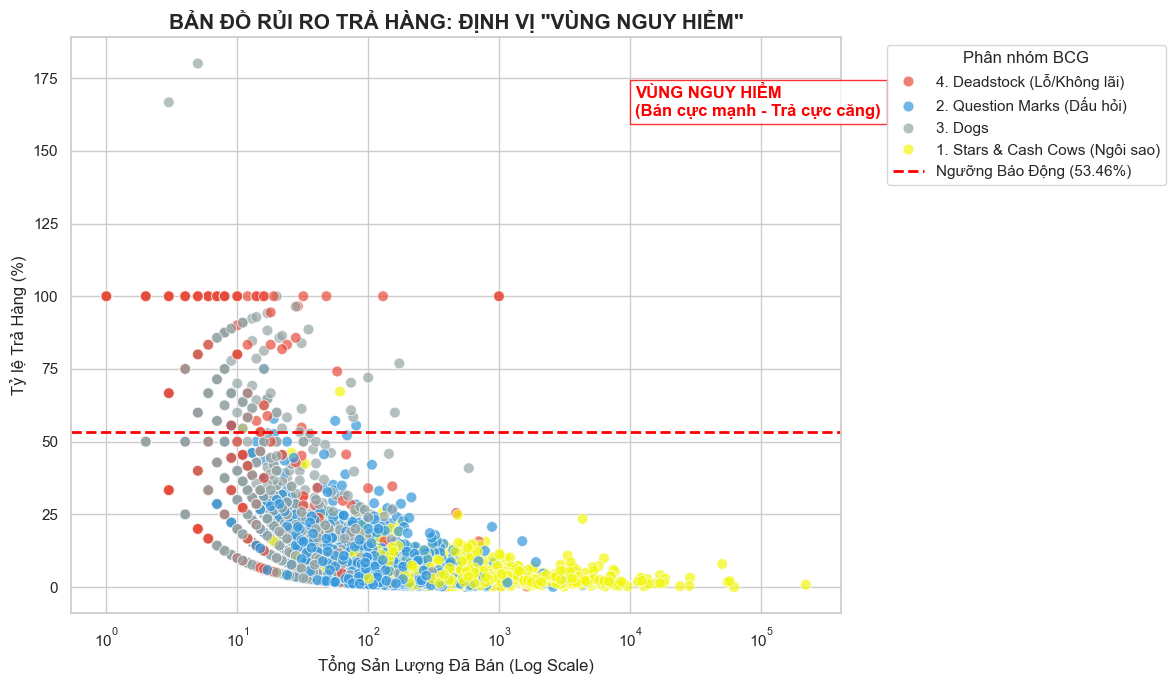

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Vẽ Bản đồ Rủi ro")

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Chỉ đưa lên biểu đồ những mã có bị trả hàng (để biểu đồ đỡ bị 1 đường ngang sát đáy)
plot_returns = return_analysis[return_analysis['Return_Rate_Pct'] > 0]

# Vẽ Scatter Plot, tô màu theo nhóm BCG
sns.scatterplot(
    data=plot_returns, 
    x='Total_Sold', 
    y='Return_Rate_Pct', 
    hue='BCG_Class',
    palette=['#e74c3c', '#3498db', '#95a5a6', "#f2f60d"], # Đỏ cho Ngôi Sao, Xanh cho Dấu hỏi...
    alpha=0.7, 
    s=60
)

# Chuyển trục X sang Scale Logarit vì chênh lệch sản lượng giữa các mã quá khổng lồ
plt.xscale('log') 
plt.title('BẢN ĐỒ RỦI RO TRẢ HÀNG: ĐỊNH VỊ "VÙNG NGUY HIỂM"', fontsize=15, fontweight='bold')
plt.xlabel('Tổng Sản Lượng Đã Bán (Log Scale)')
plt.ylabel('Tỷ lệ Trả Hàng (%)')

# Kẻ đường lằn ranh đỏ (Upper Bound tự động tính ở Block 1)
plt.axhline(y=upper_bound, color='red', linestyle='--', linewidth=2, label=f'Ngưỡng Báo Động ({upper_bound:.2f}%)')

# Đóng khung chú thích góc trên cùng (nơi gom tụ các mã bán nhiều - trả nhiều)
plt.text(
    x=plot_returns['Total_Sold'].max() * 0.05, 
    y=plot_returns['Return_Rate_Pct'].max() * 0.9, 
    s='VÙNG NGUY HIỂM\n(Bán cực mạnh - Trả cực căng)', 
    color='red', fontsize=12, fontweight='bold', 
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='red')
)

plt.legend(title='Phân nhóm BCG', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# TEAM NOTE: Khi báo cáo, chỉ thẳng vào những chấm ĐỎ nằm phía trên đường gạch đứt. 
# Đó là tụi "Ngôi sao" đang bòn rút tiền lưu kho và vận chuyển ngược của công ty.

### 6.2.3 Khám phá Chu kỳ trả hàng (Tìm Insights cho Model)

Xem thử đại lý hay trả hàng vào lúc nào (cuối tháng chốt sổ kế toán, hay đầu tuần). Mục đích cốt lõi là tìm quy luật để tạo ra các Boolean Flags đưa vào mô hình XGBoost/LightGBM, giúp mô hình tự động giảm mức dự báo vào những ngày đại lý hay trả hàng

Kiểm tra chu kỳ và xu hướng trả hàng (Ngày, Tuần, Tháng, Năm)


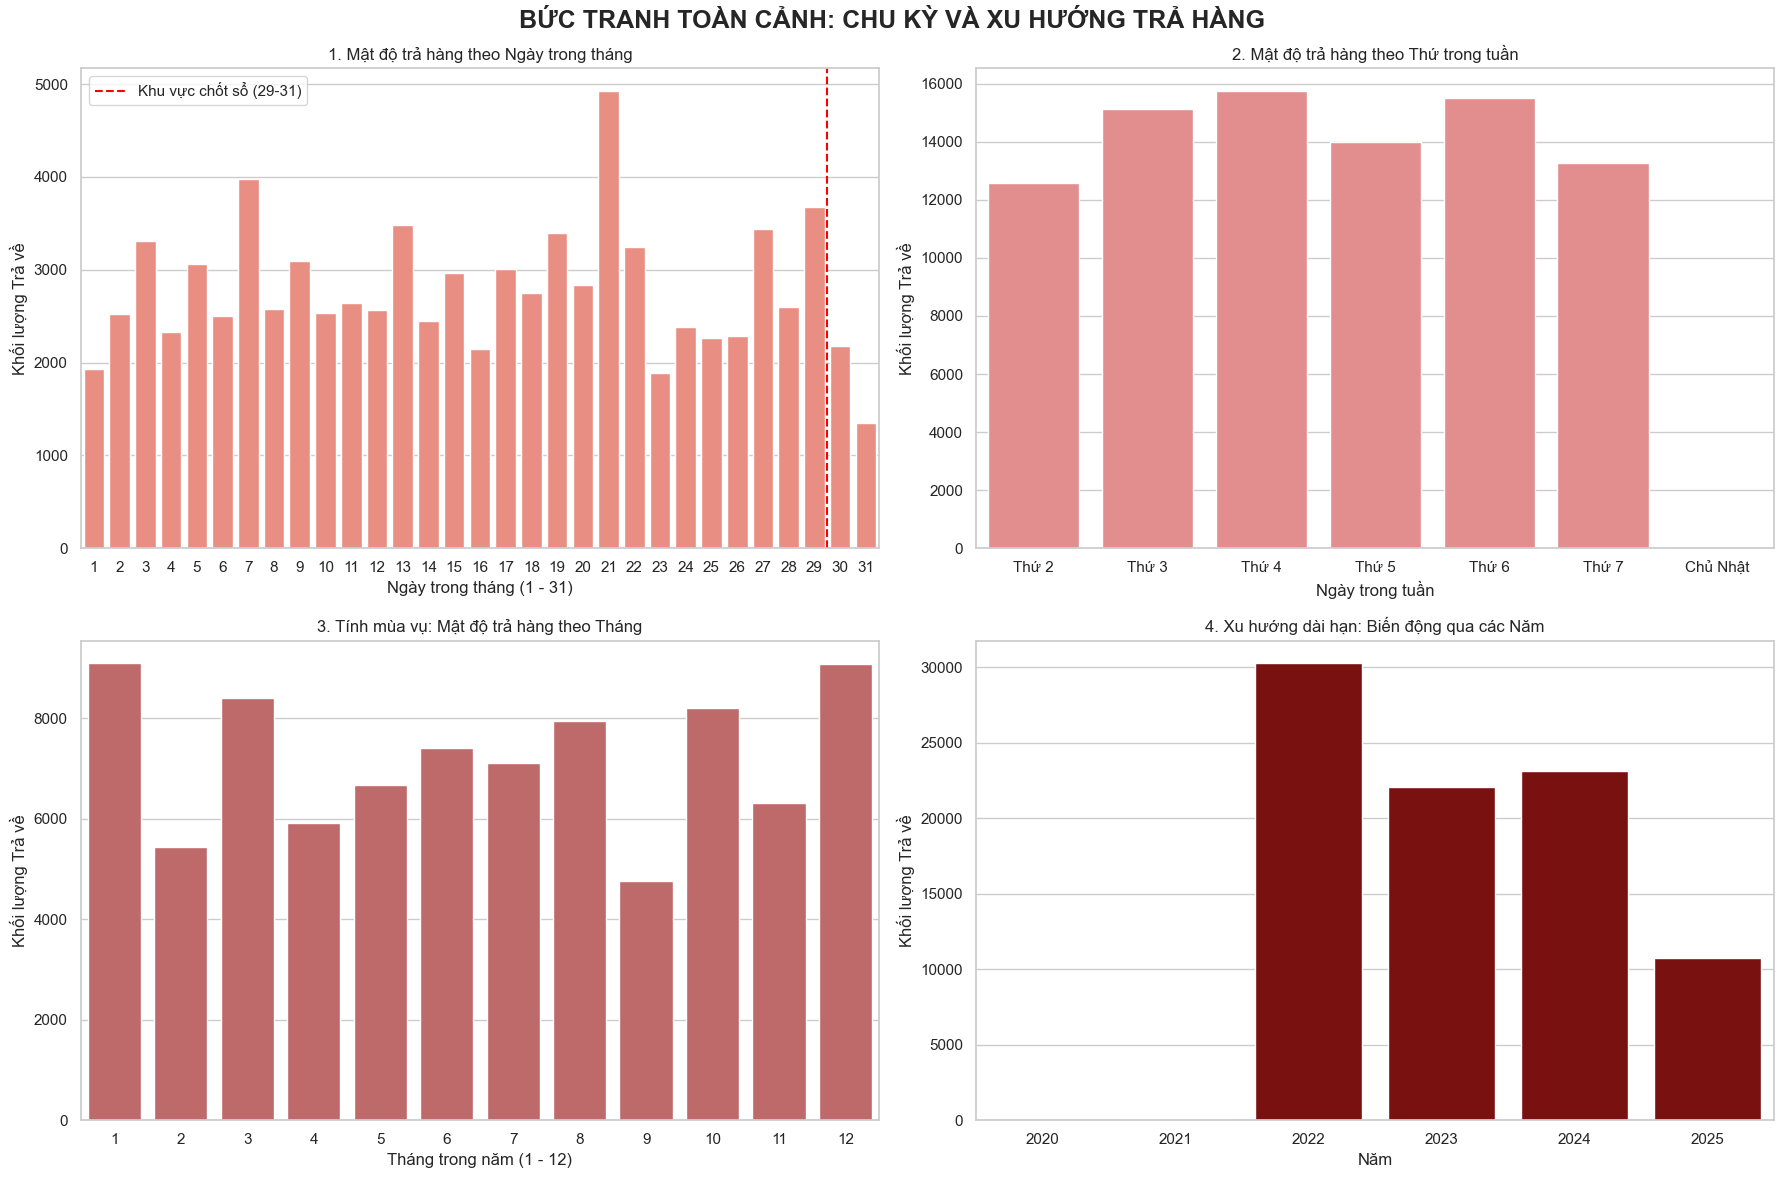

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Kiểm tra chu kỳ và xu hướng trả hàng (Ngày, Tuần, Tháng, Năm)")

# 1. Bốc riêng đám giao dịch trả hàng ra
# LƯU Ý: Dùng cờ Is_Return == 1 chuẩn xác hơn để không dính rác "điều chỉnh kho"
returns_only = train_df[train_df['Is_Return'] == 1].copy() 
returns_only['Return_Volume'] = returns_only['Quantity'].abs() # Lấy số tuyệt đối để vẽ cột cho dễ

# 2. Xé nhỏ trục thời gian thành 4 chiều
returns_only['Day_of_Month'] = returns_only['Date'].dt.day
returns_only['Day_of_Week'] = returns_only['Date'].dt.dayofweek 
returns_only['Month'] = returns_only['Date'].dt.month
returns_only['Year'] = returns_only['Date'].dt.year

# Đổi số thành chữ Tiếng Việt cho mượt (Thứ trong tuần)
day_map = {0: 'Thứ 2', 1: 'Thứ 3', 2: 'Thứ 4', 3: 'Thứ 5', 4: 'Thứ 6', 5: 'Thứ 7', 6: 'Chủ Nhật'}
returns_only['Day_Name'] = returns_only['Day_of_Week'].map(day_map)

# 3. Lên hình (Tạo Grid 2x2 chứa 4 đồ thị)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('BỨC TRANH TOÀN CẢNH: CHU KỲ VÀ XU HƯỚNG TRẢ HÀNG', fontsize=18, fontweight='bold')

# --- Đồ thị 1: Hiện tượng dồn toa cuối tháng (Góc trên trái) ---
monthly_cycle = returns_only.groupby('Day_of_Month')['Return_Volume'].sum()
sns.barplot(x=monthly_cycle.index, y=monthly_cycle.values, ax=axes[0, 0], color='salmon')
axes[0, 0].set_title('1. Mật độ trả hàng theo Ngày trong tháng', fontsize=12)
axes[0, 0].set_xlabel('Ngày trong tháng (1 - 31)')
axes[0, 0].set_ylabel('Khối lượng Trả về')
axes[0, 0].axvline(x=28.5, color='red', linestyle='--', label='Khu vực chốt sổ (29-31)')
axes[0, 0].legend()

# --- Đồ thị 2: Trả hàng theo Thứ trong tuần (Góc trên phải) ---
order_days = ['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6', 'Thứ 7', 'Chủ Nhật']
weekly_cycle = returns_only.groupby('Day_Name')['Return_Volume'].sum().reindex(order_days)
sns.barplot(x=weekly_cycle.index, y=weekly_cycle.values, ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('2. Mật độ trả hàng theo Thứ trong tuần', fontsize=12)
axes[0, 1].set_xlabel('Ngày trong tuần')
axes[0, 1].set_ylabel('Khối lượng Trả về')

# --- Đồ thị 3: Tính mùa vụ - Trả hàng theo Tháng (Góc dưới trái) ---
month_cycle = returns_only.groupby('Month')['Return_Volume'].sum()
sns.barplot(x=month_cycle.index, y=month_cycle.values, ax=axes[1, 0], color='indianred')
axes[1, 0].set_title('3. Tính mùa vụ: Mật độ trả hàng theo Tháng', fontsize=12)
axes[1, 0].set_xlabel('Tháng trong năm (1 - 12)')
axes[1, 0].set_ylabel('Khối lượng Trả về')

# --- Đồ thị 4: Xu hướng dài hạn - Trả hàng theo Năm (Góc dưới phải) ---
year_cycle = returns_only.groupby('Year')['Return_Volume'].sum()
sns.barplot(x=year_cycle.index, y=year_cycle.values, ax=axes[1, 1], color='darkred')
axes[1, 1].set_title('4. Xu hướng dài hạn: Biến động qua các Năm', fontsize=12)
axes[1, 1].set_xlabel('Năm')
axes[1, 1].set_ylabel('Khối lượng Trả về')

plt.tight_layout()
plt.show()

# TEAM NOTE ĐỂ TẠO FEATURES CHO MODEL (UPDATE):
# 1. Tháng (Mùa vụ): Nếu đồ thị (3) có đỉnh nhọn (Ví dụ: Tháng 2, 3 sau Tết bị trả hàng tồn nhiều), 
#    bắt buộc phải tạo cờ "Is_Post_Holiday_Month" để mô hình cảnh giác.
# 2. Năm (Xu hướng): Nếu đồ thị (4) có xu hướng giảm dần qua các năm, chứng tỏ chất lượng quản lý 
#    đại lý đang tốt lên. Mô hình LightGBM sẽ tự bắt được Trend này thông qua các Lag Features 
#    và Rolling Means dài hạn mà team sẽ tạo sắp tới.

## 6.3 Kiểm tra đặc tính chuỗi thời gian

Quy trình của phần này:<bt>

[Lưu ý quan trọng cho Team: Ở phần này, chúng ta BẮT BUỘC phải dùng bảng dữ liệu full_time_series (bảng đã điền đủ lịch 5 năm và lấp các ngày không bán được hàng bằng số 0). Nếu dùng bảng giao dịch gốc, nhịp thời gian sẽ bị đứt gãy và tính toán sẽ sai hoàn toàn.]<br>

Đo lường Độ thưa thớt (Sparsity):
  + Ý nghĩa: Tính xem mỗi mã hàng có bao nhiêu phần trăm thời gian là trắng bảng ko bán được gì (Quantity = 0)
  + Tác dụng cho Model: Nếu một mã hàng có độ thưa thớt > 80, dùng mô hình hồi quy bình thường (như RMSE) sẽ thất bại. Ta sẽ phải đổi hàm mục tiêu (Objective/Loss function) sang dạng Tweedie hoặc Poisson
  
Khám phá Mùa vụ & Thói quen (Seasonality & Habits):Ý nghĩa: Xem thử khách hàng hay gom hàng vào tháng mấy, thứ mấy trong tuần, hoặc ngày nào trong tháng.Tác dụng cho Model: Giúp team tạo ra các biến lịch (Calendar Features) như Is_Monday, Is_End_Of_Month, Month_of_Year.

Phân tích Tự tương quan (ACF - Autocorrelation):Ý nghĩa: Xem nhu cầu ngày hôm nay giống với ngày hôm qua (Lag 1), giống tuần trước (Lag 7) hay giống tháng trước (Lag 28).Tác dụng cho Model: Đây là "mỏ vàng" để tạo ra các biến trễ (Lag_features). Cây quyết định (XGBoost/LightGBM) sống nhờ các biến này.

### 6.3.1 Tìm ngưỡng phân chia bằng K-Means Clustering và Đo lường Sparsity

Trong chuỗi thời gian của ngành phân phối B2B, hiện tượng "trắng bảng" (nhiều ngày liên tiếp Quantity = 0) là đặc tính cố hữu<br>

Thông thường, các quy tắc kinh nghiệm thường dùng mốc cứng 80% (tức 80% số ngày trong năm không bán được hàng) để định nghĩa là nhóm "Cực kỳ thưa thớt". Tuy nhiên, với một tập dữ liệu đặc thù, việc áp đặt một con số ngẫu nhiên từ trên trời rơi xuống là thiếu cơ sở dữ liệu và dễ gây nhiễu cho mô hình<br>

Thay vì đoán mò, chúng ta sử dụng thuật toán K-Means Clustering để phân tích tỷ lệ Sparsity của toàn bộ gần 16,000 mã hàng. Thuật toán sẽ tự động tính toán khoảng cách và cắt danh mục ra thành 3 clusters có hành vi mua tự nhiên nhất:<br>

  + Nhóm 1 - Smooth (Thường xuyên): Tỷ lệ trắng bảng thấp, nhu cầu xuất hiện đều đặn

  + Nhóm 2 - Intermittent (Đứt quãng): Bán lắt nhắt cách ngày, tỷ lệ không bán được hàng ở mức trung bình

  + Nhóm 3 - Lumpy/Sparse (Rất thưa thớt): Nhu cầu cho mặt hàng này siêu thấp, có khi cả tháng mới bán được 1-2 lần

Tìm ngưỡng thưa thớt
=> Thuật toán K-Means đã tự động tìm ra các ngưỡng ranh giới:
   + Chuyển từ Thường xuyên sang Đứt quãng tại: 81.24%
   + Chuyển từ Đứt quãng sang RẤT THƯA THỚT tại: 94.98%


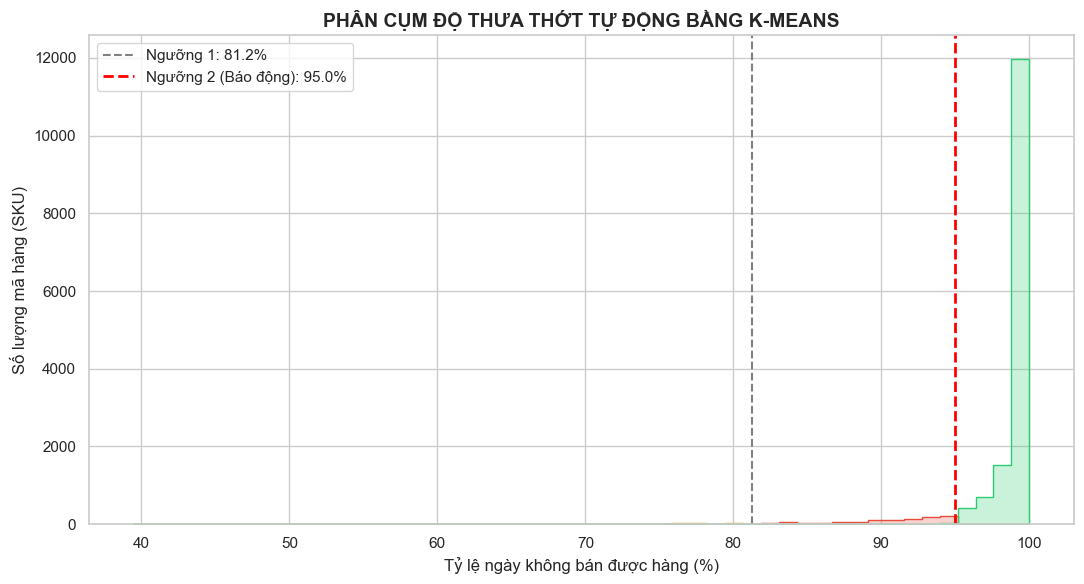

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Categorize độ thưa thớt sử dụng K-Means clustering để tìm ngưỡng đánh giá
print("Tìm ngưỡng thưa thớt")

# 1. Tính Tỷ lệ 'trắng bảng' (Sparsity_Pct) cho từng mã hàng
sparsity_df = full_time_series.groupby('ItemCode')['Quantity'].apply(
    lambda x: (x == 0).mean() * 100
).reset_index(name='Sparsity_Pct')

# 2. SỬ DỤNG K-MEANS ĐỂ TÌM NGƯỠNG TỰ ĐỘNG
# Chuyển dữ liệu thành mảng 2D để đưa vào mô hình
X = sparsity_df[['Sparsity_Pct']].values

# Gọi thuật toán K-Means chia làm 3 cụm tự nhiên
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
sparsity_df['Cluster_Label'] = kmeans.fit_predict(X)

# Sắp xếp lại tên cụm sao cho Cụm 0 luôn là thấp nhất, Cụm 2 là cao nhất (thưa thớt nhất)
cluster_centers = kmeans.cluster_centers_.flatten()
sorted_idx = np.argsort(cluster_centers)
label_mapping = {sorted_idx[0]: '1. Thường xuyên (Smooth)', 
                 sorted_idx[1]: '2. Đứt quãng (Intermittent)', 
                 sorted_idx[2]: '3. Rất thưa thớt (Lumpy/Sparse)'}
sparsity_df['Demand_Pattern'] = sparsity_df['Cluster_Label'].map(label_mapping)

# 3. TÌM THRESHOLD MÀ THUẬT TOÁN ĐÃ CHỌN
# Ranh giới là điểm lớn nhất của cụm này và nhỏ nhất của cụm kia
threshold_1 = sparsity_df[sparsity_df['Demand_Pattern'] == '1. Thường xuyên (Smooth)']['Sparsity_Pct'].max()
threshold_2 = sparsity_df[sparsity_df['Demand_Pattern'] == '2. Đứt quãng (Intermittent)']['Sparsity_Pct'].max()

print(f"=> Thuật toán K-Means đã tự động tìm ra các ngưỡng ranh giới:")
print(f"   + Chuyển từ Thường xuyên sang Đứt quãng tại: {threshold_1:.2f}%")
print(f"   + Chuyển từ Đứt quãng sang RẤT THƯA THỚT tại: {threshold_2:.2f}%")

# 4. TRỰC QUAN HÓA CÁC CỤM VÀ RANH GIỚI TỰ ĐỘNG
plt.figure(figsize=(11, 6))
sns.histplot(data=sparsity_df, x='Sparsity_Pct', hue='Demand_Pattern', 
             palette=['#2ecc71', '#f39c12', '#e74c3c'], bins=50, kde=False, element="step")

plt.title('PHÂN CỤM ĐỘ THƯA THỚT TỰ ĐỘNG BẰNG K-MEANS', fontsize=14, fontweight='bold')
plt.xlabel('Tỷ lệ ngày không bán được hàng (%)')
plt.ylabel('Số lượng mã hàng (SKU)')

# Kẻ vạch ranh giới mà thuật toán học được (Thay vì vạch 80% cứng nhắc)
plt.axvline(x=threshold_1, color='gray', linestyle='--', label=f'Ngưỡng 1: {threshold_1:.1f}%')
plt.axvline(x=threshold_2, color='red', linestyle='--', linewidth=2, label=f'Ngưỡng 2 (Báo động): {threshold_2:.1f}%')

plt.legend()
plt.tight_layout()
plt.show()

# TEAM NOTE: 
# Con số threshold_2 (màu đỏ) chính là con số vàng,  mã nào vượt qua vạch đỏ này,
# khi đưa vào mô hình LightGBM, bắt buộc phải dùng hàm loss 'tweedie' hoặc 'poisson' thay vì dùng 'rmse' bình thường dự báo sẽ ra toàn số âm hoặc số ảo

### 6.3.2 Tính mùa vụ và thói quen nhập hàng

1. Vấn đề thực tiễn (The Problem)
Thuật toán Machine Learning (như LightGBM hay XGBoost) mặc định bị mù mờ về mặt thời gian. Nếu bạn chỉ ném cho nó một cột Date dạng chuỗi (String) hoặc Datetime, nó sẽ không hiểu ngày hôm nay là Chủ Nhật hay ngày mùng 1 đầu tháng. Do đó, chúng ta phải bóc tách cột thời gian này ra để xem thực sự nhu cầu (Demand) đang bùng nổ hay chạm đáy vào những thời điểm nào.

2. Giải pháp và Hành động (Actionable Insight)
Chúng ta sẽ phân rã cột thời gian thành 3 góc độ:

Tháng trong năm (Month): Tìm ra mùa cao điểm (High Season) và mùa thấp điểm (Low Season). Ví dụ: Gần Tết các gara sửa xe nhiều nên nhu cầu phụ tùng có thể tăng vọt.

Thứ trong tuần (Day of Week): Đại lý hay gom hàng vào ngày nào nhất? Chủ Nhật họ có nghỉ bán không?

Ngày trong tháng (Day of Month): Có hiện tượng chờ để nhập hàng vào đầu tháng, hay xả quỹ chốt sổ vào cuối tháng không?

Đang bóc tách cột thời gian và phân tích thói quen gom hàng...


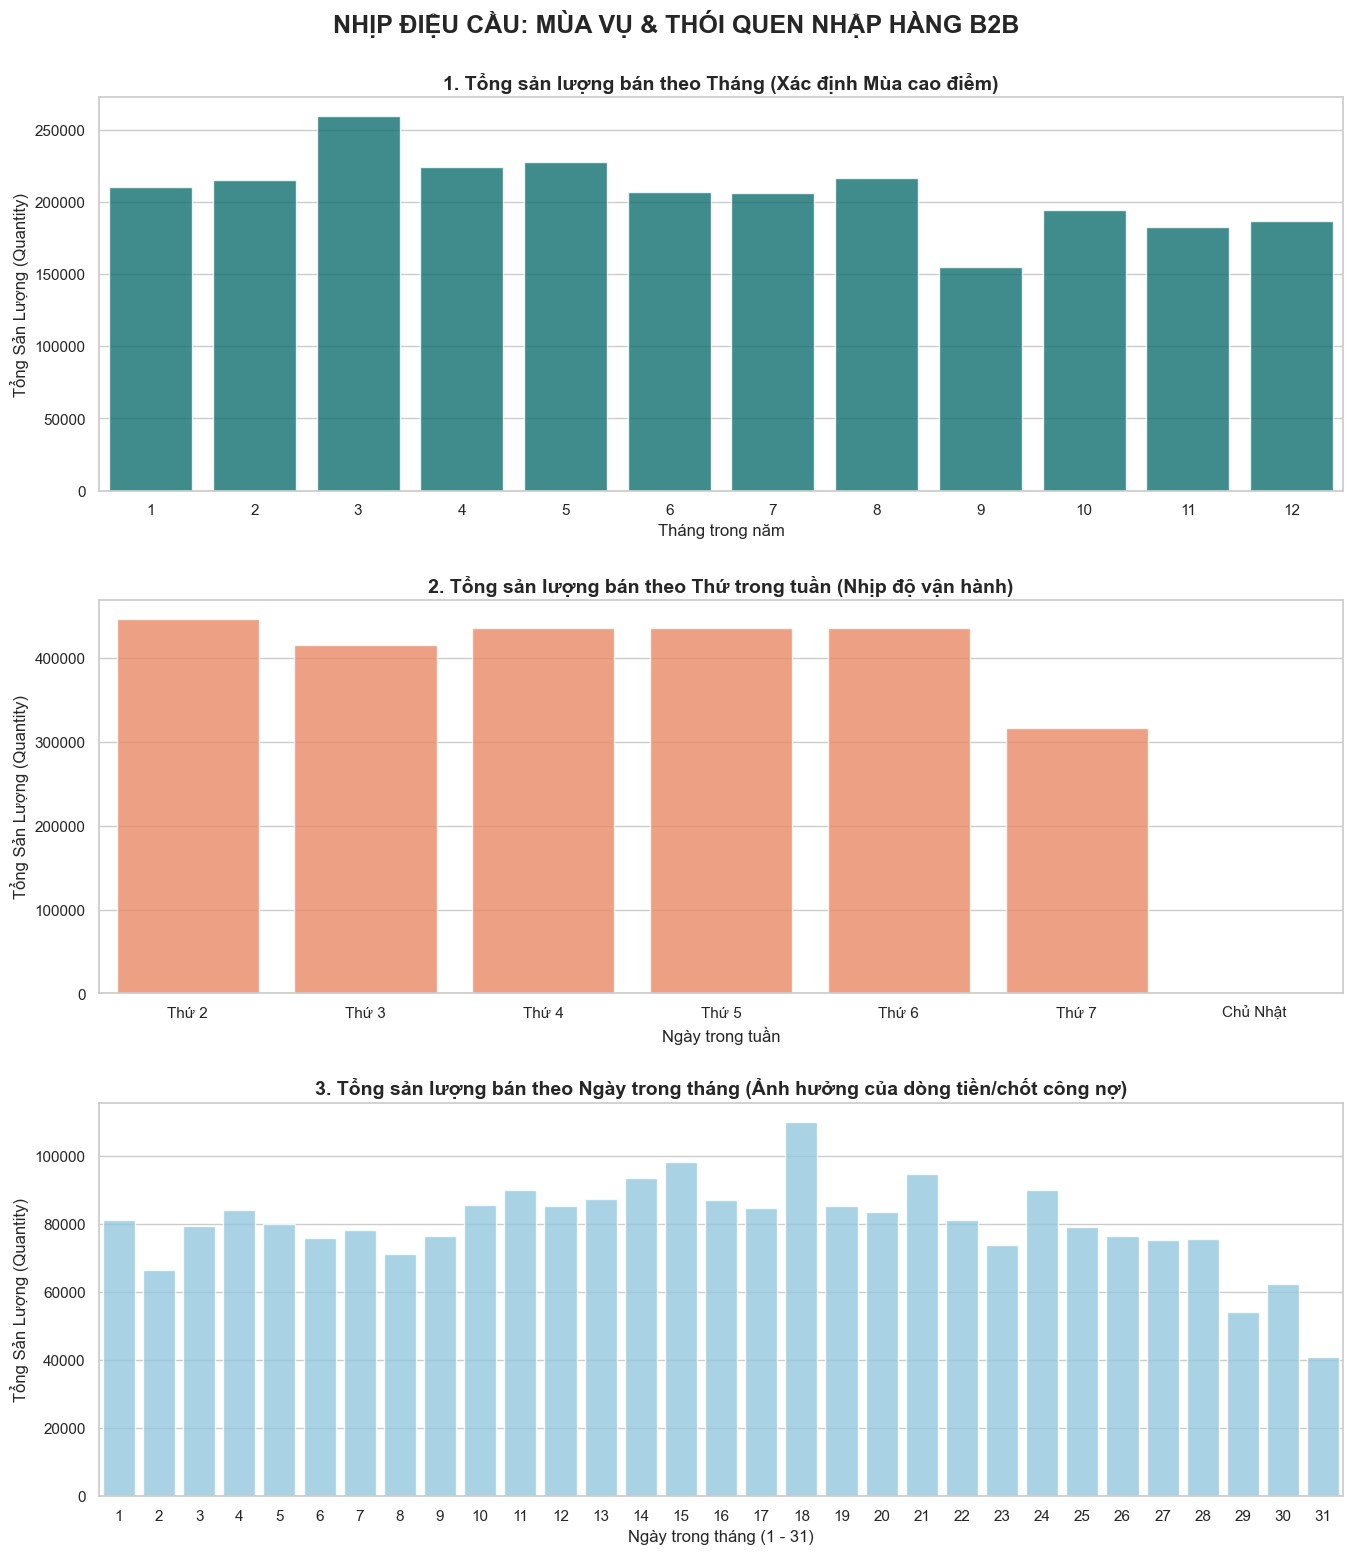

In [54]:
# --- KHÁM PHÁ MÙA VỤ VÀ THÓI QUEN NHẬP HÀNG ---
print("Đang bóc tách cột thời gian và phân tích thói quen gom hàng...")

# 1. BÓC TÁCH CÁC THÀNH PHẦN THỜI GIAN (Time Features)
# Lấy Tháng, Thứ, và Ngày từ cột Date gốc
full_time_series['Month'] = full_time_series['Date'].dt.month
full_time_series['DayOfWeek'] = full_time_series['Date'].dt.dayofweek # 0 là Thứ 2, 6 là Chủ Nhật
full_time_series['DayOfMonth'] = full_time_series['Date'].dt.day

# Map (đổi) số thứ tự thành chữ Tiếng Việt cho biểu đồ dễ đọc
day_map = {0: 'Thứ 2', 1: 'Thứ 3', 2: 'Thứ 4', 3: 'Thứ 5', 4: 'Thứ 6', 5: 'Thứ 7', 6: 'Chủ Nhật'}
full_time_series['DayName'] = full_time_series['DayOfWeek'].map(day_map)

# 2. VẼ BIỂU ĐỒ TÌM QUY LUẬT (Vẽ 3 biểu đồ xếp chồng lên nhau)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(14, 16))
fig.suptitle('NHỊP ĐIỆU CẦU: MÙA VỤ & THÓI QUEN NHẬP HÀNG B2B', fontsize=18, fontweight='bold', y=0.98)

# --- Biểu đồ 1: Mùa vụ theo Tháng trong năm ---
# Tính tổng số lượng hàng bán ra theo từng tháng
monthly_sales = full_time_series.groupby('Month')['Quantity'].sum()
sns.barplot(x=monthly_sales.index, y=monthly_sales.values, ax=axes[0], color='teal', alpha=0.8)
axes[0].set_title('1. Tổng sản lượng bán theo Tháng (Xác định Mùa cao điểm)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tháng trong năm', fontsize=12)
axes[0].set_ylabel('Tổng Sản Lượng (Quantity)', fontsize=12)

# --- Biểu đồ 2: Thói quen theo Thứ trong tuần ---
# Ép thứ tự hiển thị từ Thứ 2 đến Chủ Nhật cho chuẩn lịch
order_days = ['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6', 'Thứ 7', 'Chủ Nhật']
weekly_sales = full_time_series.groupby('DayName')['Quantity'].sum().reindex(order_days)
sns.barplot(x=weekly_sales.index, y=weekly_sales.values, ax=axes[1], color='coral', alpha=0.8)
axes[1].set_title('2. Tổng sản lượng bán theo Thứ trong tuần (Nhịp độ vận hành)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ngày trong tuần', fontsize=12)
axes[1].set_ylabel('Tổng Sản Lượng (Quantity)', fontsize=12)

# --- Biểu đồ 3: Thói quen theo Ngày trong tháng ---
day_sales = full_time_series.groupby('DayOfMonth')['Quantity'].sum()
sns.barplot(x=day_sales.index, y=day_sales.values, ax=axes[2], color='skyblue', alpha=0.8)
axes[2].set_title('3. Tổng sản lượng bán theo Ngày trong tháng (Ảnh hưởng của dòng tiền/chốt công nợ)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Ngày trong tháng (1 - 31)', fontsize=12)
axes[2].set_ylabel('Tổng Sản Lượng (Quantity)', fontsize=12)

# Chỉnh layout cho đẹp và hiển thị
plt.tight_layout(pad=2.0)
plt.show()

# --- 💡 NOTE CHO TEAM FEATURE ENGINEERING ĐỌC BIỂU ĐỒ ---
# 1. Nhìn vào biểu đồ Tháng: Nếu thấy tháng 11, 12 hoặc tháng 1 cao đột biến (giai đoạn trước Tết), hãy tạo cột cờ 'Is_Pre_Tet_Season' = 1.
# 2. Nhìn vào biểu đồ Thứ: Nếu cột Chủ Nhật (hoặc Thứ 7) lún sâu sát đáy, BẮT BUỘC phải tạo cột 'Is_Sunday' = 1 hoặc 'Is_Weekend' = 1 để model tự biết mà hạ dự báo xuống.
# 3. Nhìn vào biểu đồ Ngày: Nếu ngày 1, 2, 3 (đầu tháng) và ngày 30, 31 (cuối tháng) nhô cao hơn hẳn khúc giữa tháng, hãy tạo cờ 'Is_Start_Of_Month' và 'Is_End_Of_Month'.

### 6.3.3 Phân tích ACF và PACF để định vị lag feature

Trong chuỗi cung ứng, nhu cầu nhập hàng hiếm khi xảy ra ngẫu nhiên. Nếu hôm nay đại lý nhập 100 cái lọc dầu, khả năng cao ngày mai họ sẽ không nhập nữa (Tương quan âm với Lag 1). Nhưng đúng thứ 3 tuần sau, họ lại nhập tiếp (Tương quan dương với Lag 7). Câu hỏi đặt ra là: Trong lịch sử 5 năm, những chu kỳ lặp lại này cách nhau chính xác bao nhiêu ngày? <br>

Giải pháp: Dùng Toán học để "Bắt mạch" (ACF & PACF)<br>
Chúng ta dùng 2 biểu đồ thống kê kinh điển:<br>

ACF (Autocorrelation Function): Đo lường tổng thể xem ngày hôm nay giống với các ngày trong quá khứ như thế nào. (Nó bao gồm cả hiệu ứng domino, ví dụ Lag 1 tác động lên Lag 2, Lag 2 tác động lên Lag 3).<br>

PACF (Partial Autocorrelation Function): Cắt bỏ hiệu ứng domino, chỉ đo lường tác động trực tiếp và thuần túy của một ngày trong quá khứ (ví dụ đúng ngày này tuần trước) lên ngày hôm nay.<br>

Đang chọn các mã đại diện và khử nhiễu...
=> Hội đồng đại diện (5 mã đa chiều): ['SKU-00003', 'SKU-00002', 'SKU-09760', 'SKU-09458', 'SKU-14670']


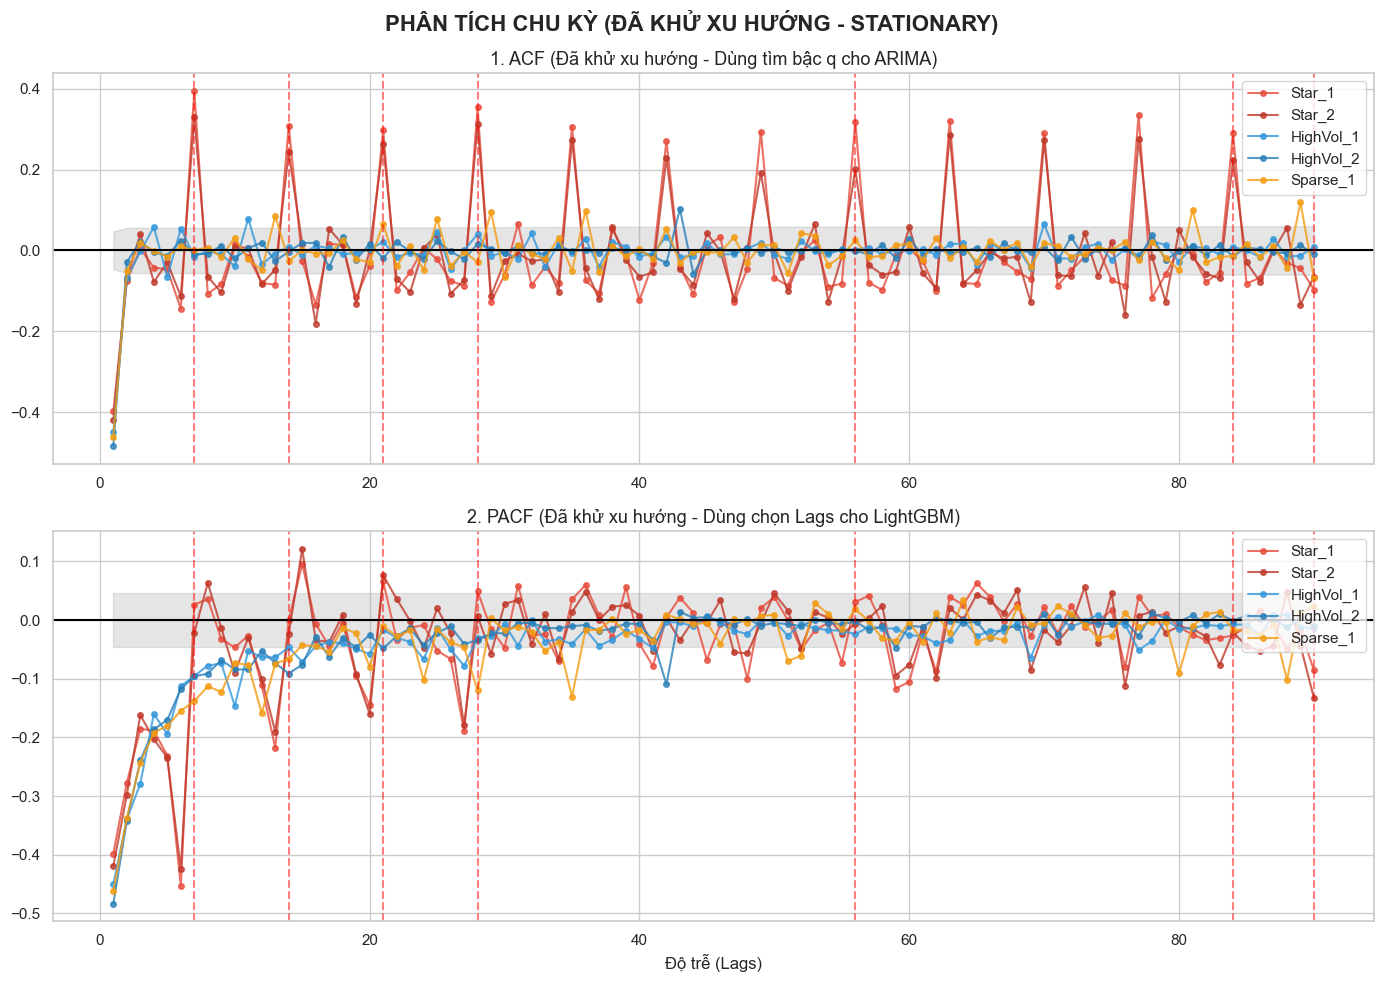

In [55]:

from statsmodels.tsa.stattools import acf, pacf

# --- BLOCK X (NÂNG CẤP TỐI THƯỢNG): TÌM CHU KỲ BẰNG STRATIFIED SAMPLING & STATIONARITY ---
print("Đang chọn các mã đại diện và khử nhiễu...")

# 1. Bốc 2 mã "Vua Lợi Nhuận" (Stars - Nhóm 1)
top_profit_items = sku_summary.nlargest(2, 'Total_Profit')['ItemCode'].tolist()

# 2. Bốc 2 mã "Vua Sản Lượng" (High Volume - Thường là các mã bán nhiều lãi ít)
# Lọc bỏ những mã đã bốc ở nhóm 1 để không trùng
volume_pool = sku_summary[~sku_summary['ItemCode'].isin(top_profit_items)]
top_volume_items = volume_pool.nlargest(2, 'Total_Volume')['ItemCode'].tolist()

# 3. Bốc 1 mã "Thưa thớt nặng" (Sparsity > 90% - Nhóm 3)
# Dùng kết quả từ cụm K-Means ở phần trước
sparse_pool = sparsity_df[sparsity_df['Demand_Pattern'] == '3. Rất thưa thớt (Lumpy/Sparse)']
sparse_item = sparse_pool.sample(1, random_state=42)['ItemCode'].tolist()

# 4. CHỐT HỘI ĐỒNG 5 MÃ
stratified_items = top_profit_items + top_volume_items + sparse_item
print(f"=> Hội đồng đại diện (5 mã đa chiều): {stratified_items}")

# 5. VẼ ĐỒ THỊ CHỒNG (OVERLAY ACF/PACF VỚI BƯỚC KHỬ XU HƯỚNG)
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('PHÂN TÍCH CHU KỲ (ĐÃ KHỬ XU HƯỚNG - STATIONARY)', fontsize=16, fontweight='bold')

max_lags = 90
labels = ['Star_1', 'Star_2', 'HighVol_1', 'HighVol_2', 'Sparse_1']
colors = ['#e74c3c', '#c0392b', '#3498db', '#2980b9', '#f39c12']

for i, item in enumerate(stratified_items):
    # Lấy dữ liệu
    ts = full_time_series[full_time_series['ItemCode'] == item].sort_values('Date')['Quantity']
    # BƯỚC QUAN TRỌNG 1: Tính sai phân (y_t - y_{t-1})
    ts_diff = ts.diff().dropna()
    
    # BƯỚC QUAN TRỌNG 2: Kiểm tra phương sai sau sai phân
    if ts_diff.std() == 0:
        print(f"Bỏ qua {item} vì dữ liệu sau sai phân toàn hằng số")
        continue
        
    # Tính ACF/PACF (Chỉ tính nếu chuỗi đủ độ dài tối thiểu để không bị lỗi)
    if len(ts_diff) > max_lags + 5:  # Cần nhiều hơn số lags để tính toán
        acf_values = acf(ts_diff, nlags=max_lags, fft=True)[1:] 
        pacf_values = pacf(ts_diff, nlags=max_lags, method='ywm')[1:]
        x_lags = np.arange(1, max_lags + 1)
        
        axes[0].plot(x_lags, acf_values, marker='o', markersize=4, color=colors[i], alpha=0.8, label=f"{labels[i]}")
        axes[1].plot(x_lags, pacf_values, marker='o', markersize=4, color=colors[i], alpha=0.8, label=f"{labels[i]}")


# Setup layout (giữ nguyên logic biểu đồ của bạn)
axes[0].set_title('1. ACF (Đã khử xu hướng - Dùng tìm bậc q cho ARIMA)', fontsize=13)
axes[0].axhline(y=0, color='black', linestyle='-')
axes[0].legend(loc='upper right')

axes[1].set_title('2. PACF (Đã khử xu hướng - Dùng chọn Lags cho LightGBM)', fontsize=13)
axes[1].set_xlabel('Độ trễ (Lags)')
axes[1].axhline(y=0, color='black', linestyle='-')
axes[1].legend(loc='upper right')

for ax in axes:
    for lag_week in [7, 14, 21, 28, 56, 84, 90]:  # Các mốc tuần và tháng phổ biến
        ax.axvline(x=lag_week, color='red', linestyle='--', linewidth=1.5, alpha=0.5)


# Thêm tham số alpha=0.05 (mức ý nghĩa 95%) để hiển thị vùng tin cậy (dải màu xanh)
acf_values, conf_int_acf = acf(ts_diff, nlags=max_lags, fft=True, alpha=0.05) 
pacf_values, conf_int_pacf = pacf(ts_diff, nlags=max_lags, method='ywm', alpha=0.05)

# ACF values trả về kèm [conf_int] nên ta lấy [1:] để bỏ Lag 0
acf_values = acf_values[1:]
# Vẽ dải tin cậy cho biểu đồ ACF (phần này nâng cao thẩm mỹ)
axes[0].fill_between(x_lags, conf_int_acf[1:, 0]-acf_values, conf_int_acf[1:, 1]-acf_values, alpha=0.2, color='gray')

# PACF cũng tương tự
pacf_values = pacf_values[1:]
axes[1].fill_between(x_lags, conf_int_pacf[1:, 0]-pacf_values, conf_int_pacf[1:, 1]-pacf_values, alpha=0.2, color='gray')


plt.tight_layout()
plt.show()

## 6.4 Phân tích vòng đời sản phẩm và xu hướng vi vĩ mô

Các mô hình học máy (Machine Learning) mặc định hoạt động theo kiểu: "Tương lai là sự lặp lại của quá khứ"<br>

Nhưng mà, trong ngành phân phối phụ tùng ô tô kéo dài suốt 5 năm (2020 - 2025), quy luật này có thể bị phá vỡ bởi 2 yếu tố: <br>

  + Yếu tố vĩ mô: Những cú sốc bất khả kháng như đại dịch COVID-19 (2021) khiến toàn bộ thị trường đóng băng, đứt gãy chuỗi cung ứng
  + Yếu tố vi mô (Vòng đời sản phẩm): Phụ tùng ô tô gắn liền với vòng đời của các dòng xe --> Khi một dòng xe lỗi thời, phụ tùng của nó sẽ rơi vào pha giảm. Ngược lại, các mã hàng mới nhập về lại chưa có đủ lịch sử để mô hình học các chu kỳ Lags  

Do đó mình sẽ có 4 hướng phân tích để tìm hướng đi cho model:<br>

Hướng 1: Xu hướng Toàn cục (Macro Trend)<br>
  + Nhiệm vụ: Đánh giá tổng sản lượng toàn công ty trong 5 năm. Chúng ta đang trên đà tăng trưởng tự nhiên hay đang suy thoái?
  + Tác động Model: Giúp mô hình bắt được trendline trước khi cộng thêm các biến động mùa vụ

Hướng 2: Nhận diện bất thường (Macro Shocks / COVID-19) <br>
  + Nhiệm vụ: Dùng trực quan hóa để khoanh vùng các điểm sụt giảm bất thường (Anomaly)
  + Tác động Model: Nếu không nhận diện và cắm cờ (Flag) cho giai đoạn COVID-19, mô hình sẽ học nhầm dữ liệu đứt gãy này và dự báo nhu cầu tương lai thấp đi một cách vô lý

Hướng 3: Lọc Mã hàng Lỗi thời (End of Life - EOL SKUs)<br>
  + Nhiệm vụ: Tìm các mã hàng có xu hướng cắm đầu đi xuống qua từng năm và gần như đóng băng giao dịch trong những tháng gần nhất
  + Tác động Model: Tránh lãng phí tài nguyên GPU. Thay vì dự báo phức tạp, team Modeling có thể dùng quy tắc Heuristic: Ép dự báo bằng 0 cho toàn bộ các mã EOL này

Hướng 4: Khoanh vùng Hàng Mới (Cold Start SKUs)<br>
  + Nhiệm vụ: Lọc ra các mã hàng mới xuất hiện dưới 6 tháng
  + Tác động Model: Cảnh báo team Model KHÔNG ĐƯỢC dùng các biến Lag_28 hay Lag_90 cho nhóm này (vì không đủ dữ liệu để lùi về quá khứ). Buộc phải dùng chiến lược Global Model (vay mượn quy luật từ các mã bán chạy khác).

### 6.4.1 Macro Trend & Anomalies

**Mục tiêu Kép (Dual Objectives)**
* **Xu hướng Toàn cục (Macro Trend):** Đánh giá sức khoẻ tổng thể của toàn công ty trong 5 năm (2020 - 2025). Công ty đang trên đà tăng trưởng hay suy thoái? Việc xác định đúng Base Trend giúp mô hình có một đường neo cơ sở vững chắc trước khi cộng thêm các biến động mùa vụ
* **Cú sốc Vĩ mô (Macro Shocks):** Tìm kiếm và khoanh vùng các điểm sụt giảm bất thường (Anomaly). Điển hình là giai đoạn từ cuối 2020 đến hết Quý 3/2021, thị trường bị đứt gãy nặng nề do đại dịch COVID-19

**Tác động cốt lõi đến Mô hình (Modeling Action)**
Nếu bỏ qua bước này, mô hình sẽ học nhầm dữ liệu đứt gãy của năm 2021 và tự động dự báo nhu cầu tương lai thấp đi một cách vô lý. 
=> **Hành động:** Trực quan hóa giai đoạn đứt gãy, đồng thời tạo ngay một feature flag `Is_Macro_Shock` để cô lập vùng nhiễu này, báo hiệu cho cây quyết định (LightGBM/XGBoost) biết đây là sự kiện bất khả kháng không được phép lặp lại.

Đang tổng hợp sản lượng và phân tích tính mùa vụ...


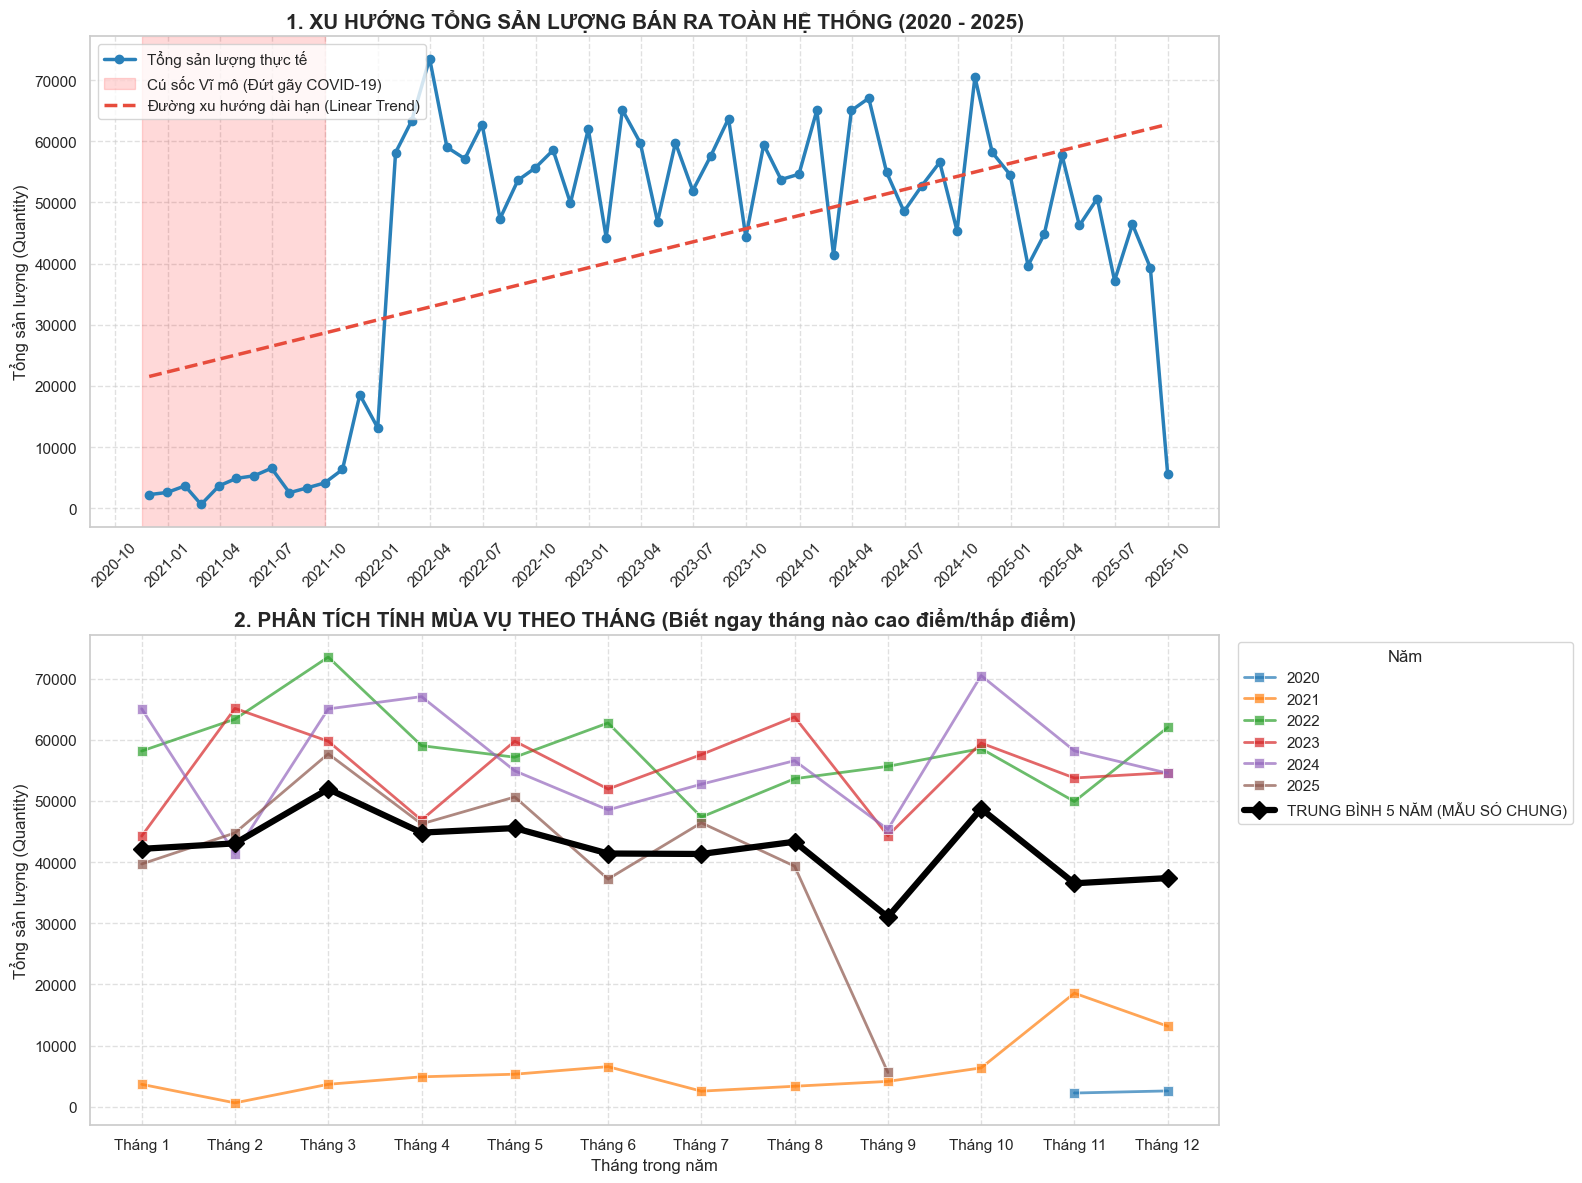


=> TEAM MODELING NOTE: Đã tạo thành công cờ 'Is_Macro_Shock'.
=> INSIGHT MÙA VỤ: Tháng cao điểm nhất thường là Tháng 3, và thấp điểm nhất là Tháng 9.
=> Khuyến nghị Team Model: Phải đưa biến 'Month' (từ 1-12) vào làm Categorical Feature để mô hình học được nhịp đập này!


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# --- 6.4.1 PHÂN TÍCH XU HƯỚNG TOÀN CỤC & TÍNH MÙA VỤ VĨ MÔ ---
print("Đang tổng hợp sản lượng và phân tích tính mùa vụ...")

# 1. Tính tổng Quantity của tất cả SKU theo từng ngày
daily_total_sales = full_time_series.groupby('Date')['Quantity'].sum().reset_index()

# 2. Resample theo Tháng để làm mượt đường xu hướng
daily_total_sales.set_index('Date', inplace=True)
monthly_total_sales = daily_total_sales.resample('ME')['Quantity'].sum().reset_index()

# Trích xuất Năm và Tháng để phân tích mùa vụ (Seasonality)
monthly_total_sales['Year'] = monthly_total_sales['Date'].dt.year
monthly_total_sales['Month'] = monthly_total_sales['Date'].dt.month

# 3. VẼ DASHBOARD 2 BIỂU ĐỒ (MACRO TREND & SEASONALITY)
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# ==========================================
# BIỂU ĐỒ 1: XU HƯỚNG VĨ MÔ & CÚ SỐC COVID (Kéo dài 5 năm)
# ==========================================
axes[0].plot(monthly_total_sales['Date'], monthly_total_sales['Quantity'], 
             marker='o', linestyle='-', color='#2980b9', linewidth=2.5, markersize=6, label='Tổng sản lượng thực tế')

axes[0].set_title('1. XU HƯỚNG TỔNG SẢN LƯỢNG BÁN RA TOÀN HỆ THỐNG (2020 - 2025)', fontsize=15, fontweight='bold')
axes[0].set_ylabel('Tổng sản lượng (Quantity)', fontsize=12)

# Khoanh vùng cú sốc COVID-19
lockdown_start = pd.to_datetime('2020-11-17')
lockdown_end = pd.to_datetime('2021-09-30')
axes[0].axvspan(lockdown_start, lockdown_end, color='red', alpha=0.15, label='Cú sốc Vĩ mô (Đứt gãy COVID-19)')

# Thêm Trend line
x_num = mdates.date2num(monthly_total_sales['Date'])
z = np.polyfit(x_num, monthly_total_sales['Quantity'], 1)
p = np.poly1d(z)
axes[0].plot(monthly_total_sales['Date'], p(x_num), color='#e74c3c', linestyle='--', linewidth=2.5, label='Đường xu hướng dài hạn (Linear Trend)')

axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(loc='upper left', fontsize=11)

# ==========================================
# BIỂU ĐỒ 2: TÍNH MÙA VỤ THEO THÁNG (YEAR-OVER-YEAR SEASONALITY)
# ==========================================
# Vẽ đường doanh thu của từng năm chồng lên nhau
sns.lineplot(data=monthly_total_sales, x='Month', y='Quantity', hue='Year', 
             palette='tab10', marker='s', linewidth=2, markersize=7, ax=axes[1], alpha=0.7)

# TÍNH VÀ VẼ ĐƯỜNG TRUNG BÌNH 5 NĂM (Đường màu đen nét đậm)
avg_monthly = monthly_total_sales.groupby('Month')['Quantity'].mean()
axes[1].plot(avg_monthly.index, avg_monthly.values, color='black', linestyle='-', linewidth=4.5, 
             marker='D', markersize=9, label='TRUNG BÌNH 5 NĂM (MẪU SỐ CHUNG)', zorder=10)

axes[1].set_title('2. PHÂN TÍCH TÍNH MÙA VỤ THEO THÁNG (Biết ngay tháng nào cao điểm/thấp điểm)', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Tháng trong năm', fontsize=12)
axes[1].set_ylabel('Tổng sản lượng (Quantity)', fontsize=12)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels([f'Tháng {i}' for i in range(1, 13)])
axes[1].grid(True, linestyle='--', alpha=0.6)

# Đưa legend ra ngoài để không che biểu đồ
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, labels, title='Năm', loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

# =====================================================================
# 4. CHUYỂN HÓA INSIGHT THÀNH FEATURE CHO TEAM MODELING
# =====================================================================
# Cờ 1: Cú sốc Vĩ mô
full_time_series['Is_Macro_Shock'] = 0
mask_shock = (full_time_series['Date'] >= lockdown_start) & (full_time_series['Date'] <= lockdown_end)
full_time_series.loc[mask_shock, 'Is_Macro_Shock'] = 1

print("\n=> TEAM MODELING NOTE: Đã tạo thành công cờ 'Is_Macro_Shock'.")

# Bổ sung insight về Tháng từ biểu đồ 2 (Gợi ý cho team Model)
peak_month = avg_monthly.idxmax()
low_month = avg_monthly.idxmin()
print(f"=> INSIGHT MÙA VỤ: Tháng cao điểm nhất thường là Tháng {peak_month}, và thấp điểm nhất là Tháng {low_month}.")
print("=> Khuyến nghị Team Model: Phải đưa biến 'Month' (từ 1-12) vào làm Categorical Feature để mô hình học được nhịp đập này!")

### 6.4.2 Kiểm tra và lọc các SKU Lỗi thời

**Tiêu chí**
Làm sao để biết một mã hàng đang "ngủ đông" tạm thời hay đã "chết lâm sàng"? 
Chúng ta sử dụng chỉ số **Days Since Last Sale** (Số ngày kể từ lần xuất kho cuối cùng). Nếu một mã hàng đã không phát sinh bất kỳ một giao dịch bán ra nào trong vòng **180 ngày (6 tháng)** tính đến ngày cuối cùng của tập dữ liệu, nó sẽ bị gắn cờ Lỗi thời (`Is_EOL = 1`).

**Tác động tới Mô hình**
* **Tiết kiệm tài nguyên:** Nhóm EOL thường chiếm số lượng lớn (đuôi dài) nhưng mang lại lợi nhuận tiệm cận 0. Tuyệt đối KHÔNG đưa nhóm này vào huấn luyện cùng các mô hình cây phức tạp (LightGBM/XGBoost) để tránh làm loãng quy luật.
* **Chiến lược Zero-Forecasting:** Giao cho team Model tách riêng nhóm `Is_EOL = 1` này ra và áp dụng dự báo bằng 0 (Zero-forecast) cho toàn bộ 56 ngày trong tập Test, hoặc áp dụng một hàm trung bình động (Moving Average) với trọng số cực kỳ nhỏ để phòng hờ rủi ro.

In [57]:
# TÌM NGƯỠNG EOL TỰ ĐỘNG BẰNG DỮ LIỆU 
print("Đang phân tích khoảng cách giữa các lần bán hàng để tìm ngưỡng EOL...")

# 1. Chỉ lấy các dòng có bán hàng
df_sales = full_time_series[full_time_series['Quantity'] > 0].copy()

# 2. Tính khoảng cách giữa 2 lần bán liên tiếp cho từng SKU
df_sales['Prev_Date'] = df_sales.groupby('ItemCode')['Date'].shift(1)
df_sales['Diff_Days'] = (df_sales['Date'] - df_sales['Prev_Date']).dt.days

# 3. Gom tất cả các khoảng cách này lại để xem phân phối
all_interarrival_times = df_sales['Diff_Days'].dropna()

# 4. Tìm phân vị thứ 99 (Tail Point)
# Chúng ta định nghĩa: Nếu một SKU có khoảng cách giữa các lần bán vượt quá 
# phân vị thứ 99 (tức là 99% các giao dịch trong hệ thống đều nhanh hơn mức này)
# thì mã đó đã rơi vào vùng "bất thường" (lỗi thời hoặc không còn nhu cầu).
auto_eol_threshold = np.percentile(all_interarrival_times, 99)

print(f"=> Ngưỡng EOL dựa trên phân vị 99% của dữ liệu là: {auto_eol_threshold:.0f} ngày.")


Đang phân tích khoảng cách giữa các lần bán hàng để tìm ngưỡng EOL...
=> Ngưỡng EOL dựa trên phân vị 99% của dữ liệu là: 274 ngày.


Đang quét vòng đời sản phẩm để tìm các mã đã 'chết lâm sàng'...
=> THỐNG KÊ VÒNG ĐỜI SẢN PHẨM:
   + Tổng số mã hàng: 15972
   + Số mã Lỗi thời (EOL): 6739 mã (42.2%) đã không bán được gì trong 274.0 ngày qua.


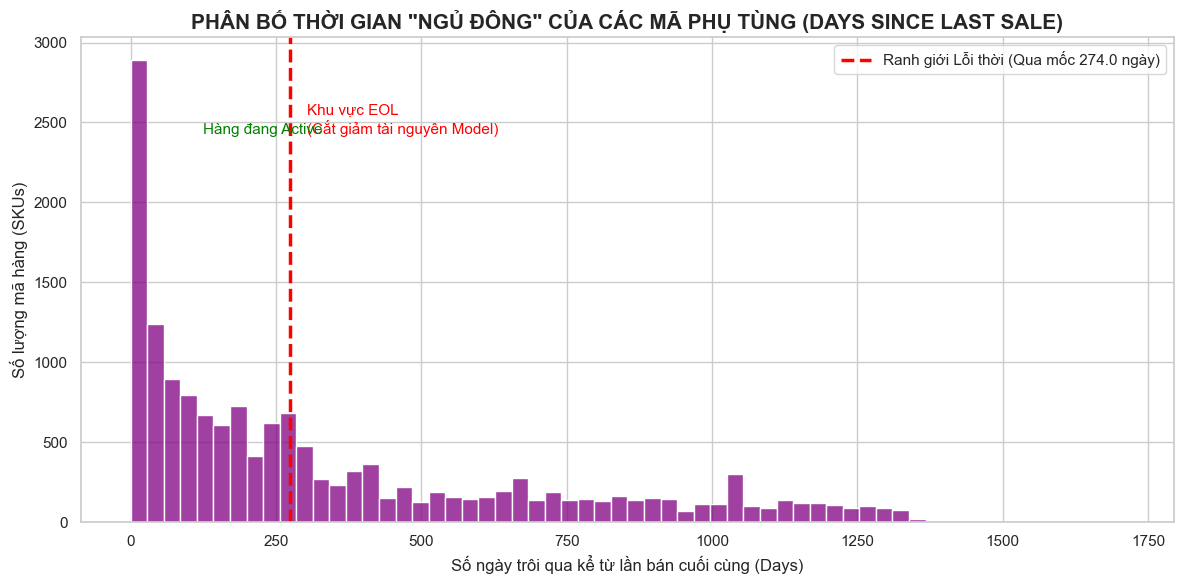

In [58]:
# NHẬN DIỆN MÃ HÀNG LỖI THỜI (END OF LIFE - EOL)
print("Đang quét vòng đời sản phẩm để tìm các mã đã 'chết lâm sàng'...")

# 1. Tìm mốc thời gian hiện tại (Ngày cuối cùng trong tập train)
current_date = full_time_series['Date'].max()

# 2. Tìm ngày bán được hàng gần nhất (Quantity > 0) cho từng mã SKU
# Chỉ tính những ngày có bán được hàng (bỏ qua những ngày Quantity = 0 hoặc bị trả hàng < 0)
sales_only = full_time_series[full_time_series['Quantity'] > 0]
last_sale_date = sales_only.groupby('ItemCode')['Date'].max().reset_index()
last_sale_date.rename(columns={'Date': 'Last_Sale_Date'}, inplace=True)

# Gộp vào danh sách tổng (để lấy cả những mã từ trước đến nay chưa từng bán được cái nào)
eol_df = pd.DataFrame({'ItemCode': full_time_series['ItemCode'].unique()})
eol_df = pd.merge(eol_df, last_sale_date, on='ItemCode', how='left')

# 3. Tính số ngày "ngủ đông" (Days Since Last Sale)
eol_df['Days_Since_Last_Sale'] = (current_date - eol_df['Last_Sale_Date']).dt.days

# Mã nào bị NaN (tức là 5 năm qua chưa bán được cái nào), ép nó bằng một số rất lớn (9999)
eol_df['Days_Since_Last_Sale'] = eol_df['Days_Since_Last_Sale'].fillna(9999)

# 4. Phân loại EOL (Ngưỡng chốt: 180 ngày ~ 6 tháng không bán được hàng)
threshold_days = auto_eol_threshold
eol_df['Is_EOL'] = (eol_df['Days_Since_Last_Sale'] >= threshold_days).astype(int)

# Thống kê nhanh để báo cáo
total_skus = len(eol_df)
eol_skus = eol_df['Is_EOL'].sum()

print(f"=> THỐNG KÊ VÒNG ĐỜI SẢN PHẨM:")
print(f"   + Tổng số mã hàng: {total_skus}")
print(f"   + Số mã Lỗi thời (EOL): {eol_skus} mã ({eol_skus/total_skus*100:.1f}%) đã không bán được gì trong {threshold_days} ngày qua.")

# 5. TRỰC QUAN HÓA THỜI GIAN NGỦ ĐÔNG
plt.figure(figsize=(12, 6))

# Vẽ biểu đồ phân phối (Bỏ qua các mã 9999 để đồ thị không bị dãn vô lý)
sns.histplot(data=eol_df[eol_df['Days_Since_Last_Sale'] < 2000], 
             x='Days_Since_Last_Sale', bins=60, color='purple', kde=False)

plt.title('PHÂN BỐ THỜI GIAN "NGỦ ĐÔNG" CỦA CÁC MÃ PHỤ TÙNG (DAYS SINCE LAST SALE)', fontsize=15, fontweight='bold')
plt.xlabel('Số ngày trôi qua kể từ lần bán cuối cùng (Days)', fontsize=12)
plt.ylabel('Số lượng mã hàng (SKUs)', fontsize=12)

# Vạch ranh giới báo động EOL
plt.axvline(x=threshold_days, color='red', linestyle='--', linewidth=2.5, 
            label=f'Ranh giới Lỗi thời (Qua mốc {threshold_days} ngày)')

# Chú thích để BGK dễ đọc
plt.text(threshold_days + 30, plt.ylim()[1]*0.8, 'Khu vực EOL\n(Cắt giảm tài nguyên Model)', color='red', fontsize=11)
plt.text(threshold_days - 150, plt.ylim()[1]*0.8, 'Hàng đang Active', color='green', fontsize=11)

plt.legend()
plt.tight_layout()
plt.show()

# TEAM MODELING NOTE:
# Lưu dataframe eol_df này lại, sau này map cột 'Is_EOL' vào tập train.
# Nếu Is_EOL == 1, team cân nhắc bỏ qua không predict bằng ML, tự động điền 0 hoặc trung bình 7 ngày gần nhất (tức là 0).

### 6.4.3 Kiểm tra và khoanh vùng các SKU mới

Đang phân tích mật độ giao dịch để xác định mã hàng Cold Start...
Cảnh báo: Có 150 SKU chưa từng bán bao giờ!
=> Ngưỡng mật độ động (5th percentile): 0.00095
=> CÓ 769 MÃ HÀNG COLD START (SKU mới dữ liệu yếu).
=> (Đã loại trừ thành công 150 mã chưa từng phát sinh giao dịch khỏi nhóm SKU mới.)


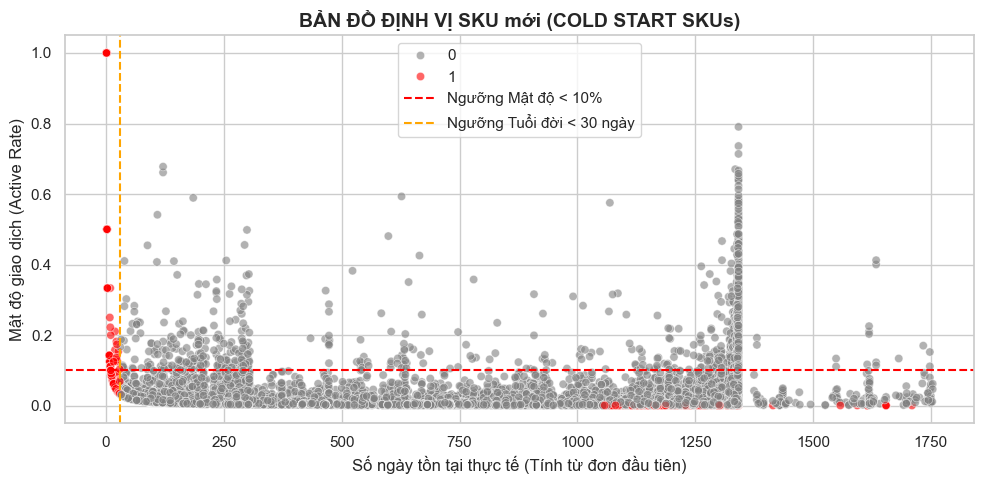

=> (Thông tin bổ sung: Hệ thống hiện có 150 mã hàng chưa từng phát sinh giao dịch trong 5 năm.)


In [59]:
# NHẬN DIỆN COLD START (DỰA TRÊN MẬT ĐỘ GIAO DỊCH) ---
print("Đang phân tích mật độ giao dịch để xác định mã hàng Cold Start...")

# 1. TÌM NGÀY BÁN ĐẦU TIÊN THỰC SỰ (Bỏ qua các ngày bị đệm số 0)
# Lọc ra các dòng có phát sinh giao dịch thực tế
active_transactions = full_time_series[full_time_series['Quantity'] != 0]

sku_metrics = active_transactions.groupby('ItemCode').agg(
    True_First_Sale_Date=('Date', 'min'), # Ngày thực tế nổ đơn đầu tiên
    Active_Days=('Date', 'count')         # Tổng số ngày có khách mua
).reset_index()

# Bổ sung lại các mã hàng "chết lâm sàng" (chưa từng bán được cái nào trong 5 năm)
all_items = pd.DataFrame({'ItemCode': full_time_series['ItemCode'].unique()})
sku_metrics = pd.merge(all_items, sku_metrics, on='ItemCode', how='left')

# 2. TÍNH TUỔI ĐỜI THỰC SỰ VÀ MẬT ĐỘ GIAO DỊCH
current_date = full_time_series['Date'].max()

# Tính tuổi đời: Nếu chưa từng bán (NaN), coi như tuổi đời cực lớn (không phải SKU mới)
sku_metrics['Total_Days'] = (current_date - sku_metrics['True_First_Sale_Date']).dt.days + 1
sku_metrics['Total_Days'] = sku_metrics['Total_Days'].fillna(9999) 
sku_metrics['Active_Days'] = sku_metrics['Active_Days'].fillna(0)


# Đảm bảo cột Total_Days là số nguyên (sau khi fillna)
sku_metrics['Total_Days'] = sku_metrics['Total_Days'].astype(int)

# Verify xem có mã nào còn bị NaN không (dự phòng)
if sku_metrics['True_First_Sale_Date'].isna().sum() > 0:
    print(f"Cảnh báo: Có {sku_metrics['True_First_Sale_Date'].isna().sum()} SKU chưa từng bán bao giờ!")

    
# Tính Active Rate (Kẹp mẫu số bằng 1 để tránh lỗi chia cho 0)
sku_metrics['Active_Rate'] = sku_metrics['Active_Days'] / sku_metrics['Total_Days'].replace(0, 1)

# 3. ĐỊNH NGHĨA COLD START ĐỘNG (DYNAMIC THRESHOLDING)
# Ta dùng phân vị thứ 5 (5%) của chính Active_Rate
# để đảm bảo chúng ta chỉ cô lập những mã hàng thực sự thưa thớt.
dynamic_threshold = np.percentile(sku_metrics['Active_Rate'], 5)

print(f"=> Ngưỡng mật độ động (5th percentile): {dynamic_threshold:.5f}")

# Cập nhật định nghĩa:
is_real_product = sku_metrics['Total_Days'] != 9999
# Cold Start = Mật độ cực thấp (< 5%) HOẶC quá trẻ (< 30 ngày)
sku_metrics['Is_Cold_Start'] = (is_real_product & 
                               ((sku_metrics['Active_Rate'] < dynamic_threshold) | 
                                (sku_metrics['Total_Days'] < 30))).astype(int)

# Thống kê
num_cold_start = sku_metrics['Is_Cold_Start'].sum()
dead_skus = (~is_real_product).sum()
print(f"=> CÓ {num_cold_start} MÃ HÀNG COLD START (SKU mới dữ liệu yếu).")
print(f"=> (Đã loại trừ thành công {dead_skus} mã chưa từng phát sinh giao dịch khỏi nhóm SKU mới.)")

# 4. TRỰC QUAN HÓA
plt.figure(figsize=(10, 5))
# Loại bỏ các mã 9999 ngày (chưa từng bán) cho biểu đồ đỡ bị méo
plot_data = sku_metrics[sku_metrics['Total_Days'] < 5000]

sns.scatterplot(data=plot_data, x='Total_Days', y='Active_Rate', hue='Is_Cold_Start', 
                palette={0: 'gray', 1: 'red'}, alpha=0.6)
plt.axhline(y=0.1, color='red', linestyle='--', label='Ngưỡng Mật độ < 10%')
plt.axvline(x=30, color='orange', linestyle='--', label='Ngưỡng Tuổi đời < 30 ngày')
plt.title('BẢN ĐỒ ĐỊNH VỊ SKU mới (COLD START SKUs)', fontsize=14, fontweight='bold')
plt.xlabel('Số ngày tồn tại thực tế (Tính từ đơn đầu tiên)')
plt.ylabel('Mật độ giao dịch (Active Rate)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"=> (Thông tin bổ sung: Hệ thống hiện có {dead_skus} mã hàng chưa từng phát sinh giao dịch trong 5 năm.)")

In [ ]:
# Kiểm tra phân phối của Active_Rate 
print(sku_metrics['Active_Rate'].describe())
print(sku_metrics['Active_Rate'].median())

count    15972.000000
mean         0.031947
std          0.069999
min          0.000000
25%          0.003508
50%          0.009209
75%          0.028550
max          1.000000
Name: Active_Rate, dtype: float64
0.009208809815569399
